In [427]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [428]:
shark_df = pd.read_excel("GSAF5.xls", engine='xlrd')
shark_df.sample(10)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
3868,24-Mar-1979,1979.0,Unprovoked,USA,Florida,"Singer Island, Riviera Beach, Palm Beach County",Surfing,Donald A. Stewart,M,27,...,Blacktip or spinner shark,"M. Vorenberg, GSAF",1979.03.24-Stewart.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1979.03.24,1979.03.24,3218.0,NaN,NaN
4974,13-Apr-1957,1957.0,Unprovoked,AUSTRALIA,Torres Strait,"Thursday Island Harbour, Queensland",Swimming between anchored pearling luggers,Tuisafua Nomoa,M,22,...,Shark seen feeding on turtle scraps thrown ove...,"J.W. Robinson; V.M. Coppleson (1958), p.245; J...",1957.04.13-Nomoa.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1957.04.13,1957.04.13,2112.0,NaN,NaN
7082,Before 1906,0.0,Unprovoked,AUSTRALIA,NaN,NaN,Fishing,fisherman,M,NaN,...,Blue pointer,"NY Sun, 9/9/1906, referring to account by Loui...",ND-0008-Fisherman2-Australia.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0008,ND.0008,9.0,NaN,NaN
2263,01-Feb-2006,2006.0,Unprovoked,TONGA,Vava'u,Tu’anuku,Swimming,Tessa Horan,F,24,...,Tiger shark,D. Clem; www.matangitonga.to,2006.02.01.b-Horan.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2006.02.01.b,2006.02.01.b,4823.0,NaN,NaN
3364,16-Apr-1991,1991.0,Unprovoked,USA,Florida,"South of Ponce Inlet, New Smyrna Beach, Volusi...","Surfing, collided with shark",David Kohler,M,22,...,1.2 m to 1.5 m [4' to 5'] shark,"Orlando Sentinel, 4/18/199, p.B3",1991.04.16.b-BaltimoreAquarium.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1991.04.16.a,1991.04.16.a,3722.0,NaN,NaN
6101,29-Mar-1915,1915.0,Unprovoked,AUSTRALIA,Torres Strait,Near Thursday Island,Skin diving for trepang but at surface next to...,Hana,M,NaN,...,3 m [10'] shark,"N. Bartlett, pp.234",1915.03.29-Hana.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1915.03.29,1915.03.29,986.0,NaN,NaN
3886,19-Jul-1978,1978.0,Provoked,USA,California,"Newport Beach, Orange County",Fishing,Harry Griffet,M,27,...,NaN,"Fresno Bee, 7/19/1978",1978.07.19-Griffet.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1978.07.19,1978.07.19,3200.0,NaN,NaN
5397,15-Jun-1945,1945.0,Unprovoked,AUSTRALIA,Queensland,"Trinity Beach, Cairns",Swimming,E. J. McHugh,M,NaN,...,NaN,"Cairns Post, 6/19/1945",1945.06.15-McHugh.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1945.06.15,1945.06.15,1689.0,NaN,NaN
4876,Mar-1959,1959.0,Watercraft,USA,Florida,Miami,"On boat, preparing to dive",R.P. Straughan,M,NaN,...,Tiger shark 4.3 m [14'],"R.P.L. Straughan; R.F. Hutton; T. Helm, p.241;",1959.03.00-Straughan.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1959.03.00,1959.03.00,2210.0,NaN,NaN
897,05-May-2017,2017.0,Unprovoked,MEXICO,Baja California Sur,"Los Arbolitos, Cabo Pulmo",Snorkeling,Andres Rozada,M,33,...,NaN,J. Rozada,2017.05.06-Rozada.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.06,2017.05.06,6187.0,NaN,NaN


In [429]:
#Copy df and overview of what we have
shark_demo_df = shark_df.copy()
shark_demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7090 entries, 0 to 7089
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7090 non-null   object 
 1   Year            7088 non-null   float64
 2   Type            7072 non-null   object 
 3   Country         7040 non-null   object 
 4   State           6603 non-null   object 
 5   Location        6523 non-null   object 
 6   Activity        6507 non-null   object 
 7   Name            6872 non-null   object 
 8   Sex             6512 non-null   object 
 9   Age             4096 non-null   object 
 10  Injury          7054 non-null   object 
 11  Fatal Y/N       6529 non-null   object 
 12  Time            3563 non-null   object 
 13  Species         3959 non-null   object 
 14  Source          7070 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

## Dropping columns

In [430]:
#names of the columns in the original file
shark_demo_df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

In [431]:
#After exploring the data, we will drop some columns that are irrelevant for our purposes
#We don't drop column 'Location' for now as it can be interesting for future campaigns for the company

shark_demo_df = shark_demo_df.drop(columns=['Date', 'Time', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1','original order', 'Unnamed: 21', 'Unnamed: 22'])
shark_demo_df.head()

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
0,2026.0,Unprovoked,Australia,Queensland,Kennedy Shoal,Spearfishing,Michael Jensz,M,39,Bite wounds to the head,Y,Undetermined Bull shark most likely
1,2026.0,Questionable,USA,Maryland,Assateague State Park,Surfing,Brendan Oster,M,?,Bite wound to the hand,N,Blue fish bite most probable
2,2026.0,Unprovoked,Australia,Western Australia,Horseshoe Reef Rottnest Island,Skindiving,Steven Mattaboni,M,38,Severe injuries both legs,Y,Great White Shark
3,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,?,Leg strpped off flesh later amputated in hospital,N,Unknown
4,2026.0,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,Bite wound to R ankle,N,Bronze Whaler


In [432]:
#Delete leading and tailing spaces
shark_demo_df.columns = shark_demo_df.columns.str.strip()

In [433]:
shark_demo_df.columns

Index(['Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name',
       'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Species'],
      dtype='object')

In [434]:
#Updated info about the df after dropping columns
print(shark_demo_df.info())
print(shark_demo_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7090 entries, 0 to 7089
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       7088 non-null   float64
 1   Type       7072 non-null   object 
 2   Country    7040 non-null   object 
 3   State      6603 non-null   object 
 4   Location   6523 non-null   object 
 5   Activity   6507 non-null   object 
 6   Name       6872 non-null   object 
 7   Sex        6512 non-null   object 
 8   Age        4096 non-null   object 
 9   Injury     7054 non-null   object 
 10  Fatal Y/N  6529 non-null   object 
 11  Species    3959 non-null   object 
dtypes: float64(1), object(11)
memory usage: 664.8+ KB
None
(7090, 12)


In [435]:
#Create a copy of the df
shark_reduced_df = shark_demo_df.copy()

## Year column

In [436]:
#Next step is to filter out year to have dataset from 2000 onwards. As year is a float it needs to be an int.
#But first we explore the nulls
print(shark_reduced_df.isnull().sum())

Year            2
Type           18
Country        50
State         487
Location      567
Activity      583
Name          218
Sex           578
Age          2994
Injury         36
Fatal Y/N     561
Species      3131
dtype: int64


In [437]:
#Print the rows where year is null
shark_reduced_df [shark_reduced_df["Year"].isnull()]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
943,NaN,Invalid,AUSTRALIA,Queensland,NaN,Spearfishing,Kerry Daniel,M,35,"No attack, shark made a threat display",NaN,Bull shark
6858,NaN,Unprovoked,ENGLAND,Cumberland,Whitehaven,Swimming,a boy,M,NaN,FATAL,Y,NaN


In [438]:
#As there are just 2 nulls we fill with 1900
shark_reduced_df = shark_reduced_df.fillna({"Year": 1900})


In [439]:
#Check if the changes have been applied
shark_reduced_df [shark_reduced_df["Year"].isnull()]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species


In [440]:
#Now create another df with the filter data from the 2000 onwards:
shark_reduced_year_df = shark_reduced_df[   shark_reduced_df["Year"] >=2000   ]
shark_reduced_year_df.sample(10)

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
1549,2012.0,Unprovoked,MEXICO,Guerrero,"Boca de la Leña, La Unión",Free diving / spearfishing,Benigno Medina Navarrete,M,46,Left hand severed,N,"Bull shark, 3m"
2724,2001.0,Provoked,AUSTRALIA,New South Wales,Bronte Beach,Snorkeling,Andranik Markossian,M,NaN,Wrist lacerated PROVOKED INCIDENT,N,Wobbegong shark
2554,2003.0,Unprovoked,AUSTRALIA,South Australia,"Goolwa Beach, Fleurieu Peninsula",Wading,Damien Smith,M,37,Ankle lacerated,N,"""a small shark"""
70,2025.0,Unprovoked,Jamaica,Montego Bay,Rose Hall beach,Paddling,Rachel Smith,F,26,minor injuries to fingers of left hand,N,Small shark 1m (3ft) long
158,2023.0,Unprovoked,AUSTRALIA,Queensland,Clack Island,Swimming,Matthew Davitt,M,21,Puncture wounds to right upper arm,N,1.8m bull shark
305,2022.0,Unprovoked,USA,New York,"Jones Beach, Nassau County",Swimming,male,M,NaN,Injury to right foot,N,Shark involvement not confirmed
543,2020.0,NaN,USA,California,"Moonlight Beach, San Diego County",Body Boarding,male,M,16,Minor injury to ankle from stingray,N,NaN
2831,2000.0,Unprovoked,SOUTH AFRICA,Western Cape Province,Struis Bay,Body surfing,Dr. Weich,M,NaN,Foot bitten,N,"White shark, 2.5 m"
1740,2010.0,Unprovoked,BAHAMAS,Abaco Islands,Elbow Cay,Surfing,Jane Engle,F,NaN,Bitten between left ankle & knee,N,Possibly a 6' lemon shark
438,2021.0,Unprovoked,FRENCH POLYNESIA,Marquesas,Ua Pou,Swimming,male,M,10,NaN,N,NaN


In [441]:
#Now create a copy of this reduced df to continue cleaning it:
shark_reduced_year_clean_df = shark_reduced_year_df.copy()

In [442]:
shark_reduced_year_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2837 entries, 0 to 2837
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       2837 non-null   float64
 1   Type       2823 non-null   object 
 2   Country    2835 non-null   object 
 3   State      2717 non-null   object 
 4   Location   2729 non-null   object 
 5   Activity   2713 non-null   object 
 6   Name       2795 non-null   object 
 7   Sex        2719 non-null   object 
 8   Age        2165 non-null   object 
 9   Injury     2828 non-null   object 
 10  Fatal Y/N  2657 non-null   object 
 11  Species    1850 non-null   object 
dtypes: float64(1), object(11)
memory usage: 288.1+ KB


In [443]:
#Now we cast Year to int:
shark_reduced_year_clean_df["Year"] = shark_reduced_year_clean_df["Year"].astype(int)
#Check the info:
shark_reduced_year_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2837 entries, 0 to 2837
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       2837 non-null   int64 
 1   Type       2823 non-null   object
 2   Country    2835 non-null   object
 3   State      2717 non-null   object
 4   Location   2729 non-null   object
 5   Activity   2713 non-null   object
 6   Name       2795 non-null   object
 7   Sex        2719 non-null   object
 8   Age        2165 non-null   object
 9   Injury     2828 non-null   object
 10  Fatal Y/N  2657 non-null   object
 11  Species    1850 non-null   object
dtypes: int64(1), object(11)
memory usage: 288.1+ KB


## Duplicated column

In [444]:
#Finding rows that are duplicated in the dataframe
print(shark_reduced_year_clean_df.duplicated().sum())

2


In [445]:
#showcasing the duplicated rows for recheck
shark_reduced_year_clean_df[shark_reduced_year_clean_df.duplicated()]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
2786,2000,Unprovoked,TANZANIA,NaN,"Coco Beach, Dar-es-Salaam",Swimming,NaN,NaN,NaN,FATAL,Y,Thought to involve a Zambesi shark
2803,2000,Unprovoked,TANZANIA,NaN,"Coco Beach, Dar-es-Salaam",Swimming,NaN,NaN,NaN,FATAL,Y,Thought to involve a Zambesi shark


In [446]:
#Dropping the two duplicate rows
shark_reduced_year_clean_df = shark_reduced_year_clean_df.drop_duplicates()

In [447]:
#check on duplicates
shark_reduced_year_clean_df[shark_reduced_year_clean_df.duplicated()]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species


In [448]:
shark_reduced_fatal_clean_df = shark_reduced_year_clean_df.copy()

## Fatal columns

In [449]:
#value count based on results published in FatalY/N column
shark_reduced_fatal_clean_df["Fatal Y/N"].value_counts()

Fatal Y/N
N          2370
Y           272
F             5
M             3
UNKNOWN       2
n             1
Nq            1
2017          1
Name: count, dtype: int64

In [450]:
#Finding uniques values in the Fatal Y/N column
print("Before:", shark_reduced_fatal_clean_df["Fatal Y/N"].unique())

Before: ['Y' 'N' 'F' 'M' nan 'n' 'Nq' 'UNKNOWN' 2017]


In [451]:
#Finding the 5 rows with F in the Fatal column
shark_reduced_fatal_clean_df[shark_reduced_fatal_clean_df["Fatal Y/N"]=="F"]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
122,2024,Unprovoked,USA,Hawaii,Goat Island (Moku'auia) La'ie Bay,Surfing,Tamayo Perry,M,49,Not specific shark bite injuries to the body,F,Not stated
245,2023,Unprovoked,NEW CALEDONIA,South Province,"Château-Royal Beach , Noumea",Swimming,Chris Davis,M,59,"FATAL, Multiple injuries",F,Bull shark
573,2019,Questionable,REUNION ISLAND,NaN,NaN,Kayaking,NaN,M,70,Partial remains recovered 12/26/2019 from shark,F,3.4 m tiger shark
579,2019,Questionable,AUSTRALIA,Queensland,"Elliot Head, near Bundaberg.",Spearfishing,Andrew Page,M,38,Believed to have drowned. Partial remains wash...,F,NaN
955,2016,Unprovoked,Mozambique,Inhambane Province,Chicuque Beac Maxixe City,Body Recovery,Male,M,40?,Body washed up on beach with signs of shark at...,F,Unknown


In [452]:
"""
Standardize values in the 'Fatal Y/N' column.

Purpose:
- Clean inconsistent labels such as 'F', 'Nq', 'M', etc.
- Convert them into standardized categories:
  Y → Fatal
  N → Non-fatal
"""

"\nStandardize values in the 'Fatal Y/N' column.\n\nPurpose:\n- Clean inconsistent labels such as 'F', 'Nq', 'M', etc.\n- Convert them into standardized categories:\n  Y → Fatal\n  N → Non-fatal\n"

In [453]:
shark_reduced_fatal_clean_df["Fatal Y/N"] = (
    shark_reduced_fatal_clean_df["Fatal Y/N"].replace({
        "F": "Y",
        "Nq": "N",
        "n": "N",
        "M": "N",
        2017: "N"
    })
)


In [454]:
shark_reduced_fatal_clean_df["Fatal Y/N"].info()

<class 'pandas.core.series.Series'>
Index: 2835 entries, 0 to 2837
Series name: Fatal Y/N
Non-Null Count  Dtype 
--------------  ----- 
2655 non-null   object
dtypes: object(1)
memory usage: 44.3+ KB


In [455]:
print("After:", shark_reduced_fatal_clean_df["Fatal Y/N"].unique())

After: ['Y' 'N' nan 'UNKNOWN']


In [456]:
shark_reduced_fatal_clean_df[shark_reduced_fatal_clean_df["Fatal Y/N"].isnull()==True]



,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species
183,2023,Unprovoked,AUSTRALIA,New South Wales,"Lighthouse Beach, Port Macquarie",Surfing,Toby Begg,M,44,Severe injuries to lower limbs,NaN,"White shark, 3.8-4.2m"
186,2023,Questionable,BAHAMAS,New Providence Isoad,"Saunders Beach, Nassau",NaN,male,M,20/30,Body found with shark bites. Possible drowning...,NaN,NaN
211,2023,Unprovoked,BAHAMAS,Freeport,Shark Junction,Scuba diving,Heidi Ernst,F,73,Calf severely bitten,NaN,Caribbean rreef shark
243,2023,Unprovoked,SEYCHELLES,Praslin Island,NaN,Snorkeling,Arthur …,M,6,Left foot bitten,NaN,Lemon shark
247,2023,Questionable,ARGENTINA,Patagonia,Chubut Province,NaN,Diego Barría,M,32,Death by misadventure,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2750,2000,Invalid,USA,Florida,"Vaughn Beach, Flagler County",Walking,Eileen Skeie,F,27,No injury,NaN,Invalid
2784,2000,Invalid,USA,North Carolina,"Emerald Isle, Carteret County",Swimming,Daniel Macatee,M,NaN,Non-fatal,NaN,Shark involvement not confirmed
2785,2000,Invalid,USA,Florida,Florida Keys,Attempting to illegally enter the USA,Juan & Alex Bueno,M,23 & 20,Shark involvement probably post-mortem,NaN,Shark involvement prior to death was not confi...
2814,2000,Invalid,AUSTRALIA,Victoria,"Koonya Beach, Melbourne",NaN,Severed human foot washed ashore (in sneaker w...,NaN,NaN,Probable drowning,NaN,Shark involvement prior to death was not confi...


In [457]:
def classify_fatal(injury):
    """
    Classifies shark attack fatality based on injury description.

    Logic:
    - If injury is missing → return 'Unknown'
    - If text suggests death → return 'Y'
    - Otherwise → return 'N'

    Parameters:
    injury (str): Description of injury field

    Returns:
    str: 'Y', 'N', or 'Unknown'
    """
    
    if pd.isna(injury):
        return "Unknown"

    text = str(injury).lower()

    # --- Unknown / Excluded (FIRST PRIORITY) ---
    unknown_keywords = [
        "not a shark", "stingray", "eel", "barracuda", "fish",
        "swordfish", "hoax", "unconfirmed", "unknown",
        "post-mortem", "post mortem", "inconsistent with shark bite",
        "not confirmed", "possible drowning", "probable drowning"
    ]

    if any(word in text for word in unknown_keywords):
        return "Unknown"

    # --- Fatal indicators ---
    fatal_keywords = [
        "fatal", "presumed fatal", "body not recovered",
        "remains recovered", "human remains", "skull found",
        "found in shark", "death", "drowned",
        "death by misadventure", "cause of death",
        "missing", "disappeared"
    ]

    if any(word in text for word in fatal_keywords):
        return "Y"

    # --- Non-fatal indicators ---
    non_fatal_keywords = [
        "injury", "injuries", "bite", "bitten", "laceration", "lacerations",
        "puncture", "cut", "cuts", "gash", "abrasion", "abrasions",
        "no injury", "none"
    ]

    if any(word in text for word in non_fatal_keywords):
        return "N"

    # Default fallback
    return "Unknown"


In [458]:
shark_reduced_fatal_clean_df["Fatal Y/N"] = shark_reduced_fatal_clean_df["Injury"].apply(classify_fatal)

In [459]:

#shark_reduced_year_clean_df.loc[
    #shark_reduced_year_clean_df["Fatal Y/N"].isna(),
    #"Fatal Y/N"
#] = shark_reduced_year_clean_df.loc[
   # shark_reduced_year_clean_df["Fatal Y/N"].isna(),
   # "Injury"
#].apply(classify_fatal)


## Injury column

In [460]:
shark_injury_clean_df = shark_reduced_fatal_clean_df.copy()

In [461]:
#number of unique values
len(shark_injury_clean_df["Injury"].unique())

1845

In [462]:
#As output is very long, gather it into a txt file so we can normalise it

In [463]:
# Get the unique injury values
unique_injuries = shark_injury_clean_df["Injury"].unique().tolist()

# Write to txt file (each item on a new line)
with open("unique_injuries.txt", "w") as f:
    for injury in unique_injuries:
        f.write(str(injury) + "\n")

print("Exported to unique_injuries.txt")


Exported to unique_injuries.txt


In [464]:

def normalize_injury(text):
    """
    Normalize injury descriptions into standardized categories.
    
    The function cleans the input text and maps keywords to categories: "Fatal" for
    death-related terms, "No injury" for no-attack cases, amputation categories with
    specific body parts (forearm, arm, hand, fingers, foot, toes, leg above/below knee),
    "Laceration", "Puncture", "Severe injury", "Bite" for common injuries, or "Other"
    when no match is found.
    """
   
    if pd.isna(text):
        return "Unknown"

    s = str(text).lower().strip()
    s = re.sub(r"\s+", " ", s)

    # Fatal
    if any(x in s for x in ["fatal", "died", "death", "body not recovered", "drowned", "remains recovered"]):
        return "Fatal"

    # No injury
    if any(x in s for x in ["no injury", "none sustained", "none to report", "no attack"]):
        return "No injury"

    # Amputation-focused
    if any(x in s for x in ["amputated", "severed", "torn off", "bitten off", "missing", "removed"]):
        if "forearm" in s:
            return "Amputation - forearm"
        if "arm" in s:
            return "Amputation - arm"
        if "hand" in s:
            return "Amputation - hand"
        if any(x in s for x in ["finger", "fingers", "thumb"]):
            return "Amputation - fingers"
        if "foot" in s:
            return "Amputation - foot"
        if any(x in s for x in ["toe", "toes"]):
            return "Amputation - toes"
        if any(x in s for x in ["leg", "lower leg", "thigh", "knee", "calf"]):
            if "above the knee" in s or "above knee" in s:
                return "Amputation - leg above knee"
            if "below the knee" in s or "below knee" in s:
                return "Amputation - leg below knee"
            return "Amputation - leg"
        return "Amputation - unspecified"

    # Other common injuries
    if "laceration" in s or "gash" in s or "cut" in s:
        return "Laceration"
    if "puncture" in s:
        return "Puncture"
    if any(x in s for x in ["severe", "serious", "deep wounds", "tissue loss", "degloved"]):
        return "Severe injury"
    if "bite" in s or "bitten" in s:
        return "Bite"

    return "Other"


In [465]:
#Create a column to not overwrite the previous one and apply it
shark_injury_clean_df["injury_normalized"] = shark_injury_clean_df["Injury"].apply(normalize_injury)

In [466]:
shark_injury_clean_df["injury_normalized"].unique().tolist()

['Bite',
 'Severe injury',
 'Amputation - leg',
 'Unknown',
 'Other',
 'Laceration',
 'Puncture',
 'No injury',
 'Amputation - arm',
 'Amputation - forearm',
 'Amputation - hand',
 'Fatal',
 'Amputation - unspecified',
 'Amputation - foot',
 'Amputation - fingers',
 'Amputation - leg above knee',
 'Amputation - leg below knee']

In [467]:
shark_injury_clean_df[shark_injury_clean_df["injury_normalized"]=="Unknown"]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized
6,2026,Unprovoked,Australia,South Australia,Cape Jaffa Limestone Coast,Diving,Luke Kuhn,M,?,NaN,Unknown,Great White Shark 3.5m (11.5ft),Unknown
240,2023,Unprovoked,AUSTRALIA,Western Australia,Cheynes Beach,Surf-sking,female,F,NaN,NaN,Unknown,5m to 6m shark,Unknown
313,2022,Unprovoked,USA,South Carolina,"Myrtle Beach, Horry County",NaN,male,M,teen,NaN,Unknown,NaN,Unknown
334,2022,Unprovoked,AUSTRALIA,New South Wales,Crowdy Baay,Swimming,male,M,NaN,NaN,Unknown,NaN,Unknown
438,2021,Unprovoked,FRENCH POLYNESIA,Marquesas,Ua Pou,Swimming,male,M,10,NaN,Unknown,NaN,Unknown
528,2020,Unprovoked,BAHAMAS,Exumas,"Pig Beach, Pig Island",NaN,NaN,NaN,NaN,NaN,Unknown,NaN,Unknown
532,2020,Unprovoked,AUSTRALIA,Western Australia,"Tantabitti Beach, Nigaloo",NaN,female,F,NaN,NaN,Unknown,NaN,Unknown
2028,2008,Unprovoked,AUSTRALIA,New South Wales,Crescent Head,NaN,Jamie Adlington,M,NaN,NaN,Unknown,"Tiger shark, 2.3m",Unknown
2124,2007,Invalid,SENEGAL,NaN,NaN,Murder,Alex Takyi,NaN,NaN,NaN,Unknown,Questionable Incident,Unknown


In [468]:
shark_injury_clean_df.sample(10)

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized
2476,2003,Unprovoked,SOUTH AFRICA,KwaZulu-Natal,Sodwana,Spearfishing,Seldon Jee,M,21,"Presumed FATAL, severed hand recovered",Y,"Tiger shark, 4 m [13'] ?",Fatal
2329,2005,Unprovoked,USA,North Carolina,"Holden Beach, Brunswick County",Swimming,Chris Humphrey,M,22,Lacerations of left forearm,N,[4.5' to 5'] shark,Laceration
2438,2004,Invalid,TONGA,Nuku'alofa,30 nautical miles offshore,Five men on makeshift raft after their 10 m fi...,male 1,M,NaN,He was was bitten on the arm by small sharks &...,Y,Questionable Incident,Fatal
2055,2008,Unprovoked,USA,Florida,"Playalinda Beach, Canaveral National Seashore,...",Surfing,Jordan Marsden,M,20,Left foot bitten,N,a small shark,Bite
1835,2009,Watercraft,AUSTRALIA,Victoria,Portland,Kayaking,Rhys Gadsden,M,27,"No injury, shark bit kayak",N,"White shark, 4m",No injury
2454,2004,Unprovoked,AUSTRALIA,New South Wales,"Taree, Old Bar Beach",Swimming,male,M,NaN,Three toes lacerated,Unknown,NaN,Other
1553,2012,Watercraft,USA,California,"Leffingwell Landing, Cambria, San Luis Obispo...",Kayaking / Fishing,Joey Nocchi,M,30,"No injury, kayaker fell in the water when kaya...",N,White shark,No injury
683,2018,Unprovoked,NEW ZEALAND,North Island,Matauri Bay,Spearfishing,Kevin Lloyd,M,24,Injuries to leg and hand,N,"Mako shark, 7'",Other
1484,2012,Unprovoked,USA,California,"Humboldt Bay, Eureka, Humboldt County",Surfing,Scott Stephens,M,25,Multiple lacerations to torso,N,White shark,Laceration
611,2019,Unprovoked,USA,Hawaii,"Makaha Beach, Oahu",Surfing,Max Keliikipi,M,16,"No injury, board damaged",N,10' to 12' shark,No injury


In [469]:
#Let's categorise them into broader groups for display information summary at the end:

In [470]:
#It takes previous work made with normalization and cathegorises it:
def injury_category(injury_type):

    """
    Categorize normalized injury types into broader injury categories.
    
    The function maps injury types from normalize_injury() to three main categories:
    "Amputation" for any amputation-type injuries, "Severe Injury" for severe injury
    and puncture cases, "Minor Injury" for bite, laceration, other, and unspecified
    types. Fatal, No injury, and Unknown values are returned unchanged.
    """
    
    if pd.isna(injury_type):
        return "Unknown"

    if injury_type.startswith("Amputation"):
        return "Amputation"

    # Only truly severe terms
    if injury_type in ["Severe injury", "Puncture"]:
        return "Severe Injury"

    # Bite, Laceration, Other → Minor
    if injury_type in ["Bite", "Laceration", "Other"]:
        return "Minor Injury"

    if injury_type in ["Fatal", "No injury", "Unknown"]:
        return injury_type

    return "Minor Injury"


In [471]:
# Creating a new column for the groups:

shark_injury_clean_df["injury_group"] = shark_injury_clean_df["injury_normalized"].apply(injury_category)


In [472]:
shark_injury_clean_df.sample(10)

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized,injury_group
887,2017,Unprovoked,AUSTRALIA,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,NaN,"No injury, knocked off board",N,Seven-gill shark,No injury,No injury
1020,2016,Provoked,AUSTRALIA,Western Australia,Coral Bay,Spearfishing,Brad Vale,M,19,No injury but shark punctured his wetsuit afte...,N,5' shark,No injury,No injury
1862,2009,Unprovoked,VIETNAM,Binh Dinh Province,Quy Nhon,Swimming,Hoang Thi Thuy Hong,F,41,Foot bitten,N,NaN,Bite,Minor Injury
839,2017,Watercraft,AUSTRALIA,Westerm Australia,Esperance,Fishing,NaN,NaN,NaN,"sharks rammed boats, no injury to occupants",N,"White shark, 3.5m",No injury,No injury
773,2018,Unprovoked,MALDIVES,Alifu Alifu Atoll,Madoogali,Fishing,Ahmed Rasheed,M,32,5-inch cut to hand,N,Tiger shark,Laceration,Minor Injury
2487,2003,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Surfing,Jeffrey Hauser,M,46,Laceration on right ankle & heel,Unknown,NaN,Laceration,Minor Injury
877,2017,Invalid,COMOROS,Anjouan,Moya,Fishing,NaN,NaN,NaN,"Skull found in shark, a probable drowning & sc...",Unknown,Shark involvement prior to death not confirmed,Other,Minor Injury
287,2022,Unprovoked,ENGLAND,Cornwall,Penzance,Snorkeling,female,F,NaN,Minor injury to leg,N,Blue shark,Other,Minor Injury
689,2018,Unprovoked,AUSTRALIA,New South Wales,"7 Mile Beach, Gerroa",Surfing,male,M,24,Injuries to calf and hand,N,NaN,Other,Minor Injury
392,2021,Unprovoked,USA,California,"Capitola Beach, Santa Cruz County",Surfing,Jennifer Romney,F,NaN,No injury,N,NaN,No injury,No injury


In [473]:
shark_reduced_age_clean_df = shark_injury_clean_df.copy()

## Age column

In [474]:
#Finding uniques values in the Age column
print("Before:", shark_reduced_age_clean_df["Age"].unique())

Before: ['39' '?' '38' '16' '22' '30+' "50's" '55' '13' '11' '27' '12' '26' '56'
 '24' '25' '61' '40' '14' '50+' '54' '48' '57' '8' '63' '9' '19' '7' '85'
 '69' '18' '66' '21' '37' '20' '42' '45' '30' '40+' '29' 35 58 29 24 20 55
 17 12 37 36 23 40 28 69 48 '60+' 57 45 61 27 38 16 68 33 30 15 41 14 43
 26 'Middle age' 18 21 49 25 46 19 65 64 nan '46' '32' '10' '64' '62' '15'
 '52' '44' '47' '59' '50' '34' '30s' '20/30' '35' '65' '20s' '77' '60'
 '49' '!2' '73' '50s' '58' '67' '17' '6' '41' '53' '68' '43' '51' '31' 39
 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M' 9 31 11 34 '!6'
 '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44 '28 & 22'
 '22, 57, 31' '60s' "20's" 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '71' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5]


In [475]:
#Assuming ages and replacing with values

shark_reduced_age_clean_df["Age"] = (
    shark_reduced_age_clean_df["Age"].replace({
        "teen": "15",
        "Teen": "15",
        "Teens": "15",
        "Middle age": "35",
        "30s": "35",
        "20/30" : "25",
        "20s" : "25",
        "a minor":"10",
        "6½" : "7",
        "mid-30s" : "35",
        "50's" : "55",
        "40+" : "45",
        "!6" : "16",
        "!!" :"11",
        "!2" : "12",
        "60+" :"65",
        "50s" : "55",
        "40s" : "45",
        "60s" : "65",
        "20's" : "25",
        "50+" : "55",
        "30+" : "55",
        "18 months" : "2",
        "M" : "18",
        "30 or 36" : "35",
        "18 or 20" : "19",
        "8 or 10" : "9",
        "40?" : "40",
        "33 or 37" : " 35",
        "12 or 13": "13",
        '21 & ?': "21"

    })
)


In [476]:
shark_reduced_age_clean_df["Age"].unique()

array(['39', '?', '38', '16', '22', '55', '13', '11', '27', '12', '26',
       '56', '24', '25', '61', '40', '14', '54', '48', '57', '8', '63',
       '9', '19', '7', '85', '69', '18', '66', '21', '37', '20', '42',
       '45', '30', '29', 35, 58, 29, 24, 20, 55, 17, 12, 37, 36, 23, 40,
       28, 69, 48, '65', 57, 45, 61, 27, 38, 16, 68, 33, 30, 15, 41, 14,
       43, 26, '35', 18, 21, 49, 25, 46, 19, 65, 64, nan, '46', '32',
       '10', '64', '62', '15', '52', '44', '47', '59', '50', '34', '77',
       '60', '49', '73', '58', '67', '17', '6', '41', '53', '68', '43',
       '51', '31', 39, 51, 10, 13, 60, 62, 8, 22, 32, 56, 42, 50, 9, 31,
       11, 34, 47, 7, 71, 59, 53, 54, 75, '45 and 15', 73, 52, 70, 4, 63,
       44, '28 & 22', '22, 57, 31', 67, 74, '9 & 60', 6, 3, 82, 66, 72,
       '23', '36', '71', '70', '2', '28', '33', '74', '3', '28 & 26', '5',
       '86', '46 & 34', '28, 23 & 30', 77, '36 & 26', 84, '\xa0 ', ' ',
       ' 35', '23 & 20', 5], dtype=object)

In [477]:
#We have detected some combined values
shark_reduced_age_clean_df['Age'][shark_reduced_age_clean_df["Age"].str.contains("&", na=False)].tolist()

['28 & 22',
 '9 & 60',
 '28 & 26',
 '46 & 34',
 '28, 23 & 30',
 '36 & 26',
 '23 & 20']

In [478]:
# The values are: 28, 22, 9, 60, 28, 26, 46, 34, 28, 23, 30, 36, 26, 21, 23, 20. The median is 27 so we will replace this values for 27.
#The median was taken instead of mean to not shift any tendency right or left


In [479]:
# 1. Replace text values with cleaner numeric values
shark_reduced_age_clean_df["Age"] = shark_reduced_age_clean_df["Age"].replace({
    "teen": "15",
    "Teen": "15",
    "Teens": "15",
    "Middle age": "35",
    "30s": "35",
    "20/30": "25",
    "20s": "25",
    "a minor": "10",
    "6½": "7",
    "mid-30s": "35",
    "50's": "55",
    "40+": "45",
    "!6": "16",
    "!!": "11",
    "!2": "12",
    "60+": "65",
    "50s": "55",
    "40s": "45",
    "60s": "65",
    "20's": "25",
    "50+": "55",
    "30+": "35",
    "18 months": "2",
    "M": "18",
    "30 or 36": "35",
    "18 or 20": "19",
    "8 or 10": "9",
    "40?": "40",
    "33 or 37": "35",
    "12 or 13": "13",
    "21 & ?": "21",
    "28 & 22": "25",
    "9 & 60": "34",
    "28 & 26": "27",
    "46 & 34": "40",
    "28, 23 & 30": "27",
    "36 & 26": "31",
    "?": np.nan,
    "\xa0 ": np.nan,
    " ": np.nan,
    " 35": "35",
    "45 and 15": "30",
    "22, 57, 31": "37",
    "Unknown": np.nan
})

# 2. Convert the column to numbers
shark_reduced_age_clean_df["Age"] = pd.to_numeric(
    shark_reduced_age_clean_df["Age"],
    errors="coerce"
)

# 3. Calculate the median
median_age = shark_reduced_age_clean_df["Age"].median()
print(f"The median of the age is {median_age}")
# 4. Fill missing values with the median
shark_reduced_age_clean_df["Age"] = shark_reduced_age_clean_df["Age"].fillna(median_age)

# 5. Convert to integer the whole column
shark_reduced_age_clean_df["Age"] = shark_reduced_age_clean_df["Age"].astype(int)


The median of the age is 28.0


In [480]:
shark_reduced_age_clean_df["Age"].unique()

array([39, 28, 38, 16, 22, 55, 13, 11, 27, 12, 26, 56, 24, 25, 61, 40, 14,
       54, 48, 57,  8, 63,  9, 19,  7, 85, 69, 18, 66, 21, 37, 20, 42, 45,
       30, 29, 35, 58, 17, 36, 23, 65, 68, 33, 15, 41, 43, 49, 46, 64, 32,
       10, 62, 52, 44, 47, 59, 50, 34, 77, 60, 73, 67,  6, 53, 51, 31, 71,
       75, 70,  4, 74,  3, 82, 72,  2,  5, 86, 84])

In [481]:
shark_reduced_age_clean_df["Age"].isnull().sum()

np.int64(0)

In [482]:
#Let's create groups per age:
# Create a new column with age groups
def categorize_age(age):
    """
    Create age categories from numerical age values.
    
    Groups typically include:
    - Child
    - Teen
    - Adult
    - Senior
    
    Purpose:
    Simplifies analysis by converting continuous age into meaningful groups.
    """
    if age <= 12:
        return "Child"
    elif age <= 19:
        return "Teenager"
    elif age <= 64:
        return "Adult"
    else:
        return "Senior"


In [483]:

# Apply the function
shark_reduced_age_clean_df["Age_Group"] = shark_reduced_age_clean_df["Age"].apply(categorize_age)


In [484]:
print(f"The top 5 ages where are the most incidents are: {shark_reduced_age_clean_df["Age_Group"].value_counts().head(5)}")

The top 5 ages where are the most incidents are: Age_Group
Adult       2124
Teenager     430
Child        213
Senior        68
Name: count, dtype: int64


In [485]:
# Get value counts of Age_Group and Country combination, show top 10
shark_reduced_age_clean_df[["Age_Group", "Country"]].value_counts().head(5)

Age_Group  Country     
Adult      USA             904
           AUSTRALIA       434
Teenager   USA             264
Child      USA             150
Adult      SOUTH AFRICA    128
Name: count, dtype: int64

In [486]:
shark_clean_country_df = shark_reduced_age_clean_df.copy()

## Country column

In [487]:
#Check unique values:
for country in shark_clean_country_df["Country"].unique():
    print(country)

Australia
USA
Maldives
Bahamas
New Caledonia
Cayman Islands
Brazil
US Virgin Islands
Mozambique
French Polynesia
Samoa
Columbia
Costa Rica
Puerto Rico
Spain
Canary Islands
South Africa
Vanuatu
Jamaica
Israel
Mexico
Philippines
Turks and Caicos
Egypt
Thailand
New Zealand
Hawaii
Honduras
Indonesia
Morocco
Belize
Maldive Islands
Tobago
AUSTRALIA
INDIA
TRINIDAD
BAHAMAS
SOUTH AFRICA
MEXICO
NEW ZEALAND
EGYPT
BELIZE
PHILIPPINES
Coral Sea
SPAIN
PORTUGAL
SAMOA
COLOMBIA
ECUADOR
FRENCH POLYNESIA
NEW CALEDONIA
TURKS and CaICOS
CUBA
BRAZIL
SEYCHELLES
ARGENTINA
FIJI
MeXICO
ENGLAND
JAPAN
INDONESIA
JAMAICA
MALDIVES
THAILAND
COLUMBIA
COSTA RICA
British Overseas Territory
CANADA
JORDAN
ST KITTS / NEVIS
ST MARTIN
PAPUA NEW GUINEA
REUNION ISLAND
ISRAEL
CHINA
IRELAND
ITALY
MALAYSIA
LIBYA
nan
MAURITIUS
SOLOMON ISLANDS
ST HELENA, British overseas territory
COMOROS
REUNION
UNITED KINGDOM
UNITED ARAB EMIRATES
CAPE VERDE
Fiji
DOMINICAN REPUBLIC
CAYMAN ISLANDS
ARUBA
MOZAMBIQUE
PUERTO RICO
ATLANTIC OCEAN
GREECE
S

In [488]:
#Make countries names in Camel Case
shark_clean_country_df["Country"] = shark_clean_country_df["Country"].astype(str).str.title()
shark_clean_country_df.sample(10)

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized,injury_group,Age_Group
2788,2000,Unprovoked,Usa,Florida,"Big Pine Key, Monroe County",Snorkeling,Andrea Nani,F,45,Leg pinched,Unknown,"Nurse shark, 1.5 m [5']",Other,Minor Injury,Adult
2199,2006,Unprovoked,Reunion,Saint-Gilles-les-Bains,"Les Aigrettes, near Boucan-Canot",Body boarding,Gérald Préau,M,27,Laceration to right calf & heel,Unknown,NaN,Laceration,Minor Injury,Adult
2600,2002,Unprovoked,Usa,North Carolina,"Emerald Isle, Carteret County",Swimming,Mary Katherine Strong,F,15,Calf bitten,N,"Bull shark, 1.8 m to 2.1 m [6' to 7']",Bite,Minor Injury,Teenager
1103,2015,Invalid,Usa,Hawaii,"Waikiki,",Surfing,male,M,32,Left foot bitten by eel,Unknown,No shark involvement,Bite,Minor Injury,Adult
2110,2007,Unprovoked,Usa,Florida,"Islamorada, Monroe County",Jumped into the water,Ashley Silverman,F,19,Lacerations to arm,N,Possibly a 10' bull shark,Laceration,Minor Injury,Teenager
2333,2005,Unprovoked,Usa,Florida,"Destin, Walton County",Swimming with boogie board,Jamie Marie Daigle,F,14,"FATAL, leg bitten",Y,1.8 m [6'] bull shark,Fatal,Fatal,Teenager
243,2023,Unprovoked,Seychelles,Praslin Island,NaN,Snorkeling,Arthur …,M,6,Left foot bitten,N,Lemon shark,Bite,Minor Injury,Child
616,2019,Unprovoked,Usa,Hawaii,Molokai Channel/,Swimming,Adherbal Treidler de Oliveira,M,49,Bite to abdomen & left leg medial thigh,N,Cookiecutter shark,Bite,Minor Injury,Adult
815,2017,Unprovoked,Australia,New South Wales,Avoca Beach,Surfing,Charlie Friar,M,25,Puncture wounds to left shoulder,N,2 m shark,Puncture,Severe Injury,Adult
2261,2006,Watercraft,Australia,South Australia,"Brighton Beach, Adelaide",Fishing,"Josh Francou, Michael Brister & Paul Bahr",M,28,No injury to occupants; shark nudged the 5.3 m...,N,4.5 m white shark,No injury,No injury,Adult


In [489]:
# Clean leading and tailing spaces
shark_clean_country_df["Country"] = shark_clean_country_df["Country"].str.strip()

In [490]:
#Check again unique values and the changes we've done

for country in shark_clean_country_df["Country"].unique():
    print(country)

Australia
Usa
Maldives
Bahamas
New Caledonia
Cayman Islands
Brazil
Us Virgin Islands
Mozambique
French Polynesia
Samoa
Columbia
Costa Rica
Puerto Rico
Spain
Canary Islands
South Africa
Vanuatu
Jamaica
Israel
Mexico
Philippines
Turks And Caicos
Egypt
Thailand
New Zealand
Hawaii
Honduras
Indonesia
Morocco
Belize
Maldive Islands
Tobago
India
Trinidad
Coral Sea
Portugal
Colombia
Ecuador
Cuba
Seychelles
Argentina
Fiji
England
Japan
British Overseas Territory
Canada
Jordan
St Kitts / Nevis
St Martin
Papua New Guinea
Reunion Island
China
Ireland
Italy
Malaysia
Libya
Nan
Mauritius
Solomon Islands
St Helena, British Overseas Territory
Comoros
Reunion
United Kingdom
United Arab Emirates
Cape Verde
Dominican Republic
Aruba
Atlantic Ocean
Greece
St. Martin
France
Trinidad & Tobago
Kiribati
Diego Garcia
Taiwan
Palestinian Territories
Guam
Nigeria
Tonga
Scotland
Croatia
Saudi Arabia
Chile
Antigua
Kenya
Russia
Turks & Caicos
United Arab Emirates (Uae)
Azores
South Korea
Malta
Vietnam
Madagascar
Panam

### Country normalisation

In [491]:
#Let's normalise it, taking out geography and grammar inconsistencies:

In [492]:
#Create a dictionary first:
country_replace_map = {
    "Columbia": "Colombia",
    "Usa": "USA",
    "Us Virgin Islands": "US Virgin Islands",
    "Maldive Islands": "Maldives",
    "Canary Islands": "Spain",
    "Puerto Rico": "USA",
    "British Overseas Territory": "United Kingdom",
    "England": "United Kingdom",
    "Scotland": "United Kingdom",
    "St Kitts / Nevis": "Saint Kitts and Nevis",
    "St Martin": "Saint Martin",
    "St. Martin": "Saint Martin",
    "St. Maartin": "Saint Martin",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "Trinidad": "Trinidad and Tobago",
    "Tobago": "Trinidad and Tobago",
    "Reunion Island": "Reunion",
    "Reunion": "Réunion",
    "Cape Verde": "Cabo Verde",
    "United Arab Emirates (Uae)": "United Arab Emirates",
    "Turks & Caicos": "Turks and Caicos",
    "Turks And Caicos": "Turks and Caicos",
    "Nevis": "Saint Kitts and Nevis",
    "Antigua": "Antigua and Barbuda",
    "Hawaii": "USA",
    "Okinawa": "Japan",
    "Azores": "Portugal",
    "Diego Garcia": "British Indian Ocean Territory",
    "Palestinian Territories": "Palestine",
    "Grand Cayman": "Cayman Islands",
}

#Now apply it:
shark_clean_country_df["Country"] = (
    shark_clean_country_df["Country"]
    .str.strip() #Removes starting or ending spaces in the column
    .replace(country_replace_map)
)

In [493]:
#Re-check values:
#Check unique values:
for country in shark_clean_country_df["Country"].unique():
    print(country)

Australia
USA
Maldives
Bahamas
New Caledonia
Cayman Islands
Brazil
US Virgin Islands
Mozambique
French Polynesia
Samoa
Colombia
Costa Rica
Spain
South Africa
Vanuatu
Jamaica
Israel
Mexico
Philippines
Turks and Caicos
Egypt
Thailand
New Zealand
Honduras
Indonesia
Morocco
Belize
Trinidad and Tobago
India
Coral Sea
Portugal
Ecuador
Cuba
Seychelles
Argentina
Fiji
United Kingdom
Japan
Canada
Jordan
Saint Kitts and Nevis
Saint Martin
Papua New Guinea
Reunion
China
Ireland
Italy
Malaysia
Libya
Nan
Mauritius
Solomon Islands
St Helena, British Overseas Territory
Comoros
Réunion
United Arab Emirates
Cabo Verde
Dominican Republic
Aruba
Atlantic Ocean
Greece
France
Kiribati
British Indian Ocean Territory
Taiwan
Palestine
Guam
Nigeria
Tonga
Croatia
Saudi Arabia
Chile
Antigua and Barbuda
Kenya
Russia
South Korea
Malta
Vietnam
Madagascar
Panama
Somalia
British Virgin Islands
Norway
Senegal
Yemen
Gulf Of Aden
Sierra Leone
Liberia
Venezuela
Sri Lanka
Uruguay
Micronesia
Caribbean Sea
Tanzania


In [494]:
print(f"The top 5 countries where are the most incidents are: {shark_clean_country_df['Country'].value_counts().head(5)}")

The top 5 countries where are the most incidents are: Country
USA             1355
Australia        583
South Africa     157
Bahamas           86
Brazil            67
Name: count, dtype: int64


In [495]:
print(f"The top states where are the most incidents are: {shark_clean_country_df["State"].value_counts().head(5)}")

The top states where are the most incidents are: State
Florida              693
New South Wales      192
Hawaii               175
California           149
Western Australia    148
Name: count, dtype: int64


In [496]:
shark_clean_country_df.head()

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized,injury_group,Age_Group
0,2026,Unprovoked,Australia,Queensland,Kennedy Shoal,Spearfishing,Michael Jensz,M,39,Bite wounds to the head,N,Undetermined Bull shark most likely,Bite,Minor Injury,Adult
1,2026,Questionable,USA,Maryland,Assateague State Park,Surfing,Brendan Oster,M,28,Bite wound to the hand,N,Blue fish bite most probable,Bite,Minor Injury,Adult
2,2026,Unprovoked,Australia,Western Australia,Horseshoe Reef Rottnest Island,Skindiving,Steven Mattaboni,M,38,Severe injuries both legs,N,Great White Shark,Severe injury,Severe Injury,Adult
3,2026,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,28,Leg strpped off flesh later amputated in hospital,Unknown,Unknown,Amputation - leg,Amputation,Adult
4,2026,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,Bite wound to R ankle,N,Bronze Whaler,Bite,Minor Injury,Teenager


## Species column

In [497]:
shark_species_clean_df = shark_clean_country_df.copy()

In [498]:
shark_species_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               2835 non-null   int64 
 1   Type               2821 non-null   object
 2   Country            2835 non-null   object
 3   State              2717 non-null   object
 4   Location           2727 non-null   object
 5   Activity           2711 non-null   object
 6   Name               2795 non-null   object
 7   Sex                2719 non-null   object
 8   Age                2835 non-null   int64 
 9   Injury             2826 non-null   object
 10  Fatal Y/N          2835 non-null   object
 11  Species            1848 non-null   object
 12  injury_normalized  2835 non-null   object
 13  injury_group       2835 non-null   object
 14  Age_Group          2835 non-null   object
dtypes: int64(2), object(13)
memory usage: 354.4+ KB


In [499]:
shark_species_clean_df.isnull().sum()

Year                   0
Type                  14
Country                0
State                118
Location             108
Activity             124
Name                  40
Sex                  116
Age                    0
Injury                 9
Fatal Y/N              0
Species              987
injury_normalized      0
injury_group           0
Age_Group              0
dtype: int64

In [500]:
#Missing around 1K values of species in the column

In [501]:
print(f"The top 5 species where are the most incidents are: {shark_species_clean_df["Species"].value_counts().head(5)}")

The top 5 species where are the most incidents are: Species
White shark                        101
Shark involvement not confirmed     58
Bull shark                          54
Tiger shark                         50
4' shark                            32
Name: count, dtype: int64


In [502]:
#Let's check unique values:

In [503]:
len(shark_species_clean_df["Species"].unique())

893

In [504]:
for specie in shark_species_clean_df["Species"].unique():
    print(specie)

Undetermined Bull shark most likely
Blue fish bite most probable
Great White Shark
Unknown
Bronze Whaler
Great White Shark 3.5m (11.5ft)
Unknown shark 5ft (1.5m)
Great White Shark 10ft (3m)
Tiger or bull shark implicated
Juvenile Tiger shark 7ft (2.1m)
Unknown bull and tiger sharks frequent the area
1.7m Seven Gill shark
Bull shark
5m shark species not determined
Suspected GWS
Unknown 
Suspected Great White Shark
Black Tip Reef Shark
3m Bull shark 
3m shark
Not stgated
Suspected Tiger shark
Nurse shark 
Tiger or Bull shark
Bronze whaler?
unknown 1.2m shark
Tiger shark 4m
Not stated
5m (16.5ft) Great White
Undetermined
Lemon shark 1.8 m (6ft)
Suspected Great White
Great White Shark est 3m (10ft)
Lemon shark
5ft (1.5m) Bull shark
Undetermined small shall shark
Undetermined 
2m Bull shark?
Sand Tiger shark
Small shark
Great White
Small shark 1m (3ft) long
Dusky sharks
Not Staed
1.5m Tiger shark
Not stated 
Mako shark
bull shark
1.8m (6ft) bull shark
Bronze whaler
Described as a large terr

In [505]:
#Let's standarise the values now:

In [506]:
def normalize_species(text):
    """
    Normalizes shark species descriptions into standardized categories.
    The function cleans the input text, maps unknown/unconfirmed values to
    "Unknown", identifies non-shark incidents as "Not a shark", matches species
    keywords against predefined rules to return named species (e.g., "White shark",
    "Tiger shark"), and falls back to size-based categories ("Shark (size 
    described)", "Shark (vague size description)") or "Other" when no match found.
    """
    
    if pd.isna(text):
        return "Unknown"

    s = str(text).lower().strip()
    s = s.replace("\xa0", " ")
    s = s.replace("“", '"').replace("”", '"').replace("’", "'")
    s = s.replace('"', '')
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r'^[\s"\'`\\[\\]()+]+|[\s"\'`\\[\\]()+]+$', '', s)

    #  1. Unknown 
    if s in {
        "", "?", ".", "unknown", "not stated", "not staed", "not stgated",
        "not specified", "undetermined", "unidentified", "unidentified species",
        "species unidentified", "species unknown", "questionable",
        "questionable incident"
    }:
        return "Unknown"

    if any(term in s for term in [
        "not confirmed", "not cofirmed", "not confirmes", "unconfirmed",
        "questionable", "doubtful", "highly doubtful", "prior to death",
        "still to be determined", "species not determined", "species unknown",
        "unknown, but", "involvement probable", "considered probable",
        "reported by media as shark attack", "shark involment not confirmed",
        "shark involvement", "thought to involve",
    ]):
        return "Unknown"

    if any(term in s for term in [
        "not stated area has tiger and galapogas sharks",
        "anglers from",
        "it was believed this was the same shark",
    ]):
        return "Unknown"

    #  2. Not a shark
    if any(term in s for term in [
        "barracuda", "stingray", "bluefish", "blue fish bite most probable",
        "eel", "toadfish", "debris", "hoax", "publicity stunt",
        "not a shark", "no shark involvement", "no shark invovlement",
        "injuries not caused by a shark", "invalid incident", "invalid",
    ]):
        return "Not a shark"

    #  3. Named species 
    rules = [
        ("White shark",              ["white shark", "great white", "suspected gws", "white xhark", "wfite shark", "while shark"]),
        ("Tiger shark",              ["tiger shark", "tiger or bull", "bull or tiger", "suspected tiger"]),
        ("Bull shark",               ["bull shark", "bu.ll", "zambesi shark", "c. leucas", "whaler or bull", "possibly a bull"]),
        ("Bronze whaler shark",      ["bronze whaler", "broze whaler", "copper shark"]),
        ("Blacktip reef shark",      ["blacktip reef"]),
        ("Blacktip shark",           ["blacktip shark", "black tipped", "atlantic blacktip", "black finned shark", "blacktip whaler", "blacktip"]),
        ("Nurse shark",              ["nurse shark", "grey nurse", "gray nurse", "tawny nurse"]),
        ("Lemon shark",              ["lemon shark", "sickelfin lemon", "sicklefin lemon"]),
        ("Sand tiger shark",         ["sand tiger", "sandtiger"]),
        ("Sandbar shark",            ["sandbar shark"]),
        ("Sand shark",               ["sand shark"]),
        ("Reef shark",               ["reef shark", "caribbean reef", "grey reef", "gray reef", "whitetip reef"]),
        ("Whitetip shark",           ["whitetip shark", "oceanic whitetip"]),
        ("Seven-gill shark",         ["7-gill", "seven gill", "sevengill", "seven-gill"]),
        ("Cookiecutter shark",       ["cookiecutter shark"]),
        ("Silvertip shark",          ["silvertip shark"]),
        ("Blue shark",               ["blue shark"]),
        ("Mako shark",               ["mako shark", "shortfin mako", "longfin mako"]),
        ("Wobbegong shark",          ["wobbegong"]),
        ("Hammerhead shark",         ["hammerhead"]),
        ("Porbeagle shark",          ["porbeagle"]),
        ("Goblin shark",             ["goblin shark"]),
        ("Dogfish",                  ["dogfish", "spurdog", "smooth hound", "smoothhound"]),
        ("Raggedtooth shark",        ["raggedtooth"]),
        ("Spinner shark",            ["spinner shark"]),
        ("Salmon shark",             ["salmon shark"]),
        ("Galapagos shark",          ["galapagos shark"]),
        ("Horn shark",               ["horn shark"]),
        ("Angel shark",              ["angel shark"]),
        ("Epaulette shark",          ["epaulette shark"]),
        ("Silky shark",              ["silky shark"]),
        ("Dusky shark",              ["dusky shark"]),
        ("Basking shark",            ["basking shark"]),
        ("Thresher shark",           ["thresher shark"]),
        ("Port Jackson shark",       ["port jackson shark"]),
        ("Cow shark",                ["cow shark"]),
        ("Starry smoothhound shark", ["starry smoothhound"]),
        ("Tope shark",               ["tope shark"]),
        ("Small catshark",           ["catshark"]),
        ("Whaler shark",             ["whaler shark"]),
        ("Brown shark",              ["brown shark", "blind or brown shark"]),
    ]

    for label, keywords in rules:
        if any(k in s for k in keywords):
            return label

    #  4. Size / vague descriptions 
    if re.search(r'\d', s) and ("shark" in s or re.search(r"[\d.]+\s*(m|ft|'|cm|kg|lb)", s)):
        return "Shark (size described)"

    verbal_size = [
        "small shark", "small sharks", "a small shark", "small brown shark",
        "large shark", "juvenile shark", "shark pup",
        "unknown shark", "grey-colored shark", "grey colored shark",
        "captive shark", "shark was seen in the area",
        "said to involve a", "described as a large terrifying animal",
        "undetermined small shall shark",
    ]
    if any(term in s for term in verbal_size):
        return "Shark (vague size description)"

    return "Other"


In [507]:
#Let's create another column to not overwrite this one so we can look back:

In [508]:
shark_species_clean_df["Species_normalized"] = shark_species_clean_df["Species"].apply(normalize_species)

In [509]:
len(shark_species_clean_df["Species_normalized"].unique())

43

In [510]:
for specie in shark_species_clean_df["Species_normalized"].unique():
    print(specie)

Bull shark
Not a shark
White shark
Unknown
Bronze whaler shark
Shark (size described)
Tiger shark
Seven-gill shark
Reef shark
Nurse shark
Lemon shark
Shark (vague size description)
Dusky shark
Mako shark
Blacktip shark
Sandbar shark
Blacktip reef shark
Raggedtooth shark
Whitetip shark
Galapagos shark
Cookiecutter shark
Blue shark
Wobbegong shark
Horn shark
Epaulette shark
Dogfish
Spinner shark
Tope shark
Angel shark
Salmon shark
Porbeagle shark
Silky shark
Hammerhead shark
Goblin shark
Cow shark
Port Jackson shark
Thresher shark
Basking shark
Sand shark
Small catshark
Silvertip shark
Brown shark
Whaler shark


In [511]:
#Check if in the "Other" category there is something left
other_unique = (
    shark_species_clean_df.loc[shark_species_clean_df["Species_normalized"] == "Other", "Species"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(sorted(other_unique))


[]


In [512]:
shark_species_clean_df[shark_species_clean_df["Species_normalized"] == "Unknown"]

,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Species,injury_normalized,injury_group,Age_Group,Species_normalized
3,2026,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,28,Leg strpped off flesh later amputated in hospital,Unknown,Unknown,Amputation - leg,Amputation,Adult,Unknown
5,2026,Unprovoked,Bahamas,Andros Island,Fresh Creek,Swimming,Australian woman,F,22,Severe injuries to R arm,N,Unknown,Severe injury,Severe Injury,Adult,Unknown
7,2026,Unprovoked,Australia,NSW,Little Avalon Beach,Surfing,Unknown,M,55,Graze injuries R leg and ankle,N,Unknown,Other,Minor Injury,Adult,Unknown
11,2026,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,55,Lacerations elbow and abdomen,N,Unknown,Laceration,Minor Injury,Adult,Unknown
15,2026,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,28,No injury shark knocked man of his board,N,Unknown,No injury,No injury,Adult,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2828,2000,Unprovoked,Australia,New South Wales,"Taronga Wharf, Athol Bay, Sydney Harbor",Swimming,Jack Dasey,M,28,Survived,Unknown,NaN,Other,Minor Injury,Adult,Unknown
2830,2000,Unprovoked,USA,Florida,"Riviera Beach, Palm Beach County",NaN,male,M,27,Right calf bitten,N,NaN,Bite,Minor Injury,Adult,Unknown
2833,2000,Unprovoked,New Zealand,South Island,Oreti Beach (reported as the 4th person bitten...,Surfing,Michael Petas,M,12,"No injury, wetsuit punctured",N,NaN,No injury,No injury,Child,Unknown
2835,2000,Watercraft,Réunion,NaN,Saint Pierre,Canoe with 3 men onboard sank,Boulabhaï Ishmael,M,28,FATAL,Y,NaN,Fatal,Fatal,Adult,Unknown


In [513]:
shark_species_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                2835 non-null   int64 
 1   Type                2821 non-null   object
 2   Country             2835 non-null   object
 3   State               2717 non-null   object
 4   Location            2727 non-null   object
 5   Activity            2711 non-null   object
 6   Name                2795 non-null   object
 7   Sex                 2719 non-null   object
 8   Age                 2835 non-null   int64 
 9   Injury              2826 non-null   object
 10  Fatal Y/N           2835 non-null   object
 11  Species             1848 non-null   object
 12  injury_normalized   2835 non-null   object
 13  injury_group        2835 non-null   object
 14  Age_Group           2835 non-null   object
 15  Species_normalized  2835 non-null   object
dtypes: int64(2), object(14)
memor

## Sex Column

In [514]:
#Create a new df to "Sex Column" from age df
# Find the unique values in gender
shark_reduced_sex_clean_df = shark_species_clean_df.copy() 
shark_reduced_sex_clean_df ["Sex"].unique()

array(['M', 'F', 'M ', '?', 'F ', nan, ' M', 'm', 'lli'], dtype=object)

In [515]:
#Number of values in Sex column: 2835
shark_reduced_sex_clean_df["Sex"]

0       M
1       M
2       M
3       M
4       M
       ..
2833    M
2834    M
2835    M
2836    M
2837    M
Name: Sex, Length: 2835, dtype: object

In [516]:
# Find the null values in Sex: 116
shark_reduced_sex_clean_df["Sex"].isnull().sum()

np.int64(116)

In [517]:
# Replace the null values in Sex for "Unknown" and check 
shark_reduced_sex_clean_df["Sex"] = shark_reduced_sex_clean_df["Sex"].fillna("Unknown")
shark_reduced_sex_clean_df["Sex"].isnull().sum()

np.int64(0)

In [518]:
# Check the update unique values in Sex
shark_reduced_sex_clean_df ["Sex"].unique()

array(['M', 'F', 'M ', '?', 'F ', 'Unknown', ' M', 'm', 'lli'],
      dtype=object)

In [519]:
# Take off unnecessary spaces on Sex values
shark_reduced_sex_clean_df["Sex"] = shark_reduced_sex_clean_df["Sex"].str.strip()
shark_reduced_sex_clean_df ["Sex"].unique()

array(['M', 'F', '?', 'Unknown', 'm', 'lli'], dtype=object)

In [520]:
# Replace '?' and 'lli' for "Unknown" using dictionary
# Change 'm' for "M" using dictionary
shark_reduced_sex_clean_df["Sex"] = shark_reduced_sex_clean_df["Sex"].replace({
    "?": "Unknown",
    "lli": "Unknown",
    "m": "M",
})
shark_reduced_sex_clean_df ["Sex"].unique()

array(['M', 'F', 'Unknown'], dtype=object)

In [521]:
#LAST STEP
#Check if the final number of values in Sex column is the same from the beggining: 2835
#Check the final unique values 

len_final_sex_clean = len(shark_reduced_sex_clean_df["Sex"])

shark_reduced_sex_clean_df["Sex"] = shark_reduced_sex_clean_df["Sex"]
uvalues_sex_clean = shark_reduced_sex_clean_df["Sex"].unique()

print(f"The final number of 'Sex Column' values is: {len_final_sex_clean}")
print(f"The final 'Sex Column' unique values are: {len(uvalues_sex_clean)}, ({uvalues_sex_clean})")

The final number of 'Sex Column' values is: 2835
The final 'Sex Column' unique values are: 3, (['M' 'F' 'Unknown'])


## Activity Column

In [522]:
shark_species_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Year                2835 non-null   int64 
 1   Type                2821 non-null   object
 2   Country             2835 non-null   object
 3   State               2717 non-null   object
 4   Location            2727 non-null   object
 5   Activity            2711 non-null   object
 6   Name                2795 non-null   object
 7   Sex                 2719 non-null   object
 8   Age                 2835 non-null   int64 
 9   Injury              2826 non-null   object
 10  Fatal Y/N           2835 non-null   object
 11  Species             1848 non-null   object
 12  injury_normalized   2835 non-null   object
 13  injury_group        2835 non-null   object
 14  Age_Group           2835 non-null   object
 15  Species_normalized  2835 non-null   object
dtypes: int64(2), object(14)
memor

In [523]:
shark_activity_clean_df = shark_reduced_sex_clean_df.copy()

In [524]:
# Activity unique has been extracted to know the common patterns and it has been classified with rules in the function below:

In [525]:
unknown_values = {
    "", "?", ".", "unknown", "not stated", "undisclosed",
    "no details", "male", "baiting" 
}

category_rules = [
    ("Surfing", [
        "surfing", "surfboard", "body surfing", "bodysurfing", "body boarding",
        "bodyboarding", "boogie boarding", "boogie-boarding", "surfng",
        "riding waves on a board", "kite surf", "kite surfing", "kitersurfing",
    ]),

    ("Swimming", [
        "swimming", "swim", "floating", "treading water", "bathing", "wading",
        "snorkeling", "snorkelling", "jumped into the water", "fell into the water",
        "jumped into river", "trailing hand in the water", "ran into the water",
        "leaving the water", "kneeling in the water", "crouching in the water",
        "crouching in 2' of water", "lying in 2 feet of water",
        "lying prone in 2' of water", "in waist-deep water", "resting on body board",
        "on a float", "riding floatation device", "dived into the water",
        "dived into sea from launch", "dived from inner-tube",
        "dived naked into the water on a bet", "dived for a coin",
        "jumped off rocks into white water", "crawling", "taking wife to beach",
        "defecating in water beneath the docks", "sittting in water with his child",
        "fell from the jetty", "fell from wharf into water",
        "fell from his father's back into the water", "knocked into the water",
        "jumping", "splashing", "body recovery", "swmming",
        "ascending from a dive", "bather", "coming ashore on a hawser",
        "fleeing across a river", "crossing the river",
        "exercising his dog in the shallows", "dragging banana seeds through the shallows",
        "jumped into water",
        "squatting", "squatting in", "squatting in the water",  
    ]),

    ("Diving", [
        "diving", "scuba", "free diving", "freediving", "skin diving",
        "hookah diving", "helmet diving", "hardhat diving", "hard hat diving",
        "sponge divers", "conch diver",
    ]),

    ("Fishing", [
        "fishing", "fihing", "spearfishing", "spear fishing", "spearishing",
        "angling", "net fishing", "line fishing", "lobster fishing", "lobstering",
        "crabbing", "shrimping", "oystering", "clamming", "seine netting",
        "beach seine netting", "scalloping", "picking opihi", "catching sardines",
        "netting pilchards", "netting menhaden", "netting shrimp", "working prawn net",
        "fisherman", "preparing to fish for jack-mackerel", "pêcheur de bichiques",
        "collecting fish", "collecting fish from net", "collecting fish in military trap",
        "collecting fish by lamplight in gully", "collecting crayfish",
        "collecting ornamental fish", "collecting aquarium specimens",
        "collecting marine specimens", "collecting shells", "gathering shells",
        "gathering fish stunned by dynamite", "collecting dynamited fish",
        "hand lining for shad", "setting crayfish pots", "watching the sardine run",
        "scooping prawns", "working near fish traps", "retrieving meat from a cage in the water",
        "hauling in net", "casting a net", "removing fish from a trap",
        "bitten while cutting shark from net", "watching seine netters",
        "dry shelling", "gigging for flounder", "catching crabs",
        "catching a turtle", "hooking into a whale", "treading for clams",
        "cleaning fish", "spearing fish", "photographing fish",
        "collecting beche-de-mer", "taking catch from a fish weir",
        "netting sharks", "attempting to net shark in shark channel",
        "catching sharks under government contract", "nsb meshing",
        "feeding fish",
        "catching", "attempting to catch", "attempting to catch a crocodile", 
    ]),

    ("Boating", [
        "boat", "canoe", "kayak", "kayaking", "kakaying", "rowing", "raft",
        "dinghy", "yacht", "sailing", "catamaran", "ship", "launch", "skiff",
        "surf ski", "surf-ski", "surf skiing", "surf-skiing", "paddling",
        "sculling", "cruising", "dropping anchor", "pulling anchor",
        "overturned skiff", "attempting to fix motor", "attaching a line at sea",
        "towing a dead whale out to sea", "moving a shark in a net",
        "vehicle plunged over cliff into the water", "crossing the bay at the ford",
        "arsinoe", "pacific seafarer of us navy",
        "sup", "stand up paddle", "standup paddle",
    ]),

    ("Board Sport", [
        "body-boarding", "body boarding", "boogie boarding", "boggie boarding",
        "wing foiling", "ocean racing", "kite-boarding", "kite boarding",
        "kite foiling", "foil-boarding", "foil boarding", "wakeboarding",
        "water-skiing", "sailboarding", "paddle skiing", "paddleskiing",
        "paddleski", "paddle-boarding", "paddle boarding", "paddleboarding",
        "skimboarding", "towing her sister on plastic ski board",
        "trailing the field in a surf race",
        "kiteboarding", "foilboarding", "jet skiing",
    ]),

    ("Shark Interaction", [
        "feeding sharks", "feeding a shark", "feeding mullet to sharks",
        "feeding prawns to captive sharks", "shark feeding", "baiting sharks",
        "chumming for sharks", "chumming for white sharks", "tagging sharks",
        "shark tagging", "shark watching", "teasing a shark", "harassing a shark",
        "shooting sharks", "killing sharks", "killing a shark",
        "attempting to kill a shark with explosives", "finning the shark",
        "holding shark's tail", "attempting to ride a shark", "attempting to lasso a shark",
        "attempting to lasso shark's tail", "touching a shark", "touching sharks",
        "petting a shark", "petting captive sharks", "measuring sharks",
        "moving captive shark", "putting hand in shark tank", "removing hook from shark",
        "removing shark from net", "removing shark from trap", "removing shark from tank",
        "pulling shark from the water", "dragging a shark", "dragging stranded shark ashore",
        "dragging stranded shark",  
        "freeing trapped shark", "attempting to free the shark",
        "attempted to return injured shark to the sea", "attempting to chase shark out to sea",
        "attempting to drive shark away from the beach", "attempting to drive shark from area",
        "restraining a beached shark", "reviving a sedated shark",
        "returning to shore, collided with shark", "accidentally stood on hooked shark's tail",
        "placed hand in disemboweled shark", "grabbed shark", "grabbing shark for a selfie",
        "slapped shark on tail", "helping men land a shark", "helping angler land a shark",
        "helping friend land hooked shark", "gaffing netted shark",
        "gaffing & attempting to bring onboard a harpooned shark",
        "harpooned shark", "spearing a shark", "shark hoisted on board liner tahiti",
        "hauling dead shark aboard", "human head found in shark",
        "feeling the shark", "pushed surfmat of a young girl out of the shark's path",
        'on a "shark hunt"', "testing anti-shark cage", "attempting to anesthetize shark",
        "feeding stingrays",
        "holding shark pup", "stepped on shark", "photographing the shark",
        "attempting to rescue a shark", "harassing sharks", "fell onto dead shark",
        "attempting to rescue an injured",
        "shark week", 
    ]),

    ("Rescue", [
        "lifesaving drill", "lifesaving exhibition", "lifeguard exercises",
        "lifeguard training exercise", "rescuing",
        "went to aid of child being menaced by the shark",
        "attempting to rescue drowning man", "attempting to rescue woman seized by shark",
        "attempting to rescue an injured", "attempting to rescue an injured & beached shark",
    ]),

    ("Research", [
        "filming", "filming a documentary", "conducting research", "scientific research",
        "underwater photography", "searching for remains of dr. marais",
        "conducting a promotional film project", "watching seals",
        "attempting to attract dolphins", "photo shoot",
        "publicity stunt", "promotional film",  
    ]),

    ("Disaster", [
        "sea disaster", "wreck", "torpedoed", "sank", "foundered", "capsized",
        "adrift", "drifted", "shelled", "destroyer", "submarine", "bombers",
        "freighter", "brig", "hms", "uss", "gambier bay", "kormoran",
        "frontenac", "leyte", "bismarck sea", "hurricane & tidal wave",
        "s.s. marine sulphur queen", "portuguese airliner", "boeing 757",
        "avianca dc-4", "argentine air force", "aircaft exploded",
        "aircraft", "plane", "air disaster", "crashed", "ditched",
        "bailing out of jet", "parachuted into pacific", "parachuted from balloon",
        "picked up wearing life jackets", "plunged into the sea", "went down",
        "loss of the schooner nomad", "burning of the s.s. missouri",
        "sinking of the dredge world atlas", "sinking of the m/v mindoro",
        "sinking of the 40' esperanza", "leicester abandoned in a hurricane",
        "captured allied soldiers", "steamer tahiti collided",
        "deserting the bark nazarene", "escaping from blackbirding vessel",
        "escaping from alacatraz", "swept out to sea by the tsunami",
        "attempting to illegally enter the usa", "on december 28, 1908",
        "probable homicide victim", "probabable drowning",
        "first known attack in sydney harbour", "disappeared 11 days earlier",
        "dropped overboard", "fell oveboard", "fell overboard", "went overboard",
        "thrown overboard", "swept overboard", "washed overboard",
        "knocked overboard", "accidentally dragged overboard from the sampan holokahana",
        "reaching for life preserver",
        "jumped overboard",
    ]),

    ("Care", [
        "washing horses", "washing a dog", "washing himself", "washing his pig",
        "washing his feet", "washing", "washing hands", "washing clothes",
        "washing clothes on stairs", "washing cooking pans",
    ]),

    ("General Activity", [
        "standing", "standing in", "standing or", "standing, collecting",
        "standing, holding", "standing, stepped", "standing in inner tube",
        "walking", "walking in",
        "sitting", "sitting in",
        "playing", "playing in", "playing football", "playing soccer", 
        "playing on", "playing with",
    ]),

    ("Beach Activity", [
        "hiking", "hiking on the beach", "sightseeing", "playing on a sandbar",
    ]),

    ("Expedition", [
        "expedition", "round-the-world expedition", "on a round-the-world expedition",
        "military ocean training",
    ]),
]

def normalize_activity(text):
    """
    Normalize activity descriptions into standardized categories.

    The function cleans the input text, maps known unknown or invalid values to
    "Unknown", matches activity keywords against predefined category rules, and
    falls back to "Murder", "Suicide", or "Other" when no category matches.
    """

    
    if pd.isna(text):
        return "Unknown"

    t = str(text).lower().replace("\xa0", " ")
    t = re.sub(r"\s+", " ", t).strip(" .?")

    if t in unknown_values:
        return "Unknown"

    for label, keywords in category_rules:
        if any(k in t for k in keywords):
            return label

    if "murder" in t:
        return "Murder"
    if "suicide" in t:
        return "Suicide"

    return "Other"


In [526]:
#Create a copy of the column to use the normalized categories:
shark_activity_clean_df["activity_normalized"] = shark_activity_clean_df["Activity"].apply(normalize_activity)

In [527]:
# Get unique values and convert to list
activity_list_clean = shark_activity_clean_df["activity_normalized"].unique().tolist()

# Remove None/NaN values
activity_list_clean = [x for x in activity_list_clean if pd.notna(x)]

# Now sort
sorted_activity_list_clean = sorted(activity_list_clean)

print(sorted_activity_list_clean)

['Beach Activity', 'Board Sport', 'Boating', 'Care', 'Disaster', 'Diving', 'Expedition', 'Fishing', 'General Activity', 'Murder', 'Other', 'Rescue', 'Research', 'Shark Interaction', 'Surfing', 'Swimming', 'Unknown']


In [528]:
#How many is categorized as Other?
print(shark_activity_clean_df[shark_activity_clean_df["activity_normalized"] == "Other"]["Activity"].value_counts().all)


<bound method Series.all of Activity
Batin    1
Name: count, dtype: int64>


In [529]:
shark_activity_clean_df["activity_normalized"].value_counts()

activity_normalized
Surfing              996
Swimming             739
Fishing              456
Diving               188
Unknown              129
Boating              110
General Activity      90
Board Sport           46
Shark Interaction     45
Disaster              15
Research               5
Rescue                 5
Care                   3
Murder                 3
Expedition             2
Beach Activity         2
Other                  1
Name: count, dtype: int64

In [530]:
shark_activity_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year                 2835 non-null   int64 
 1   Type                 2821 non-null   object
 2   Country              2835 non-null   object
 3   State                2717 non-null   object
 4   Location             2727 non-null   object
 5   Activity             2711 non-null   object
 6   Name                 2795 non-null   object
 7   Sex                  2835 non-null   object
 8   Age                  2835 non-null   int64 
 9   Injury               2826 non-null   object
 10  Fatal Y/N            2835 non-null   object
 11  Species              1848 non-null   object
 12  injury_normalized    2835 non-null   object
 13  injury_group         2835 non-null   object
 14  Age_Group            2835 non-null   object
 15  Species_normalized   2835 non-null   object
 16  activity_no

In [531]:
#Clean DF:

shark_clean_final_df = shark_activity_clean_df.copy()

In [532]:
shark_clean_final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year                 2835 non-null   int64 
 1   Type                 2821 non-null   object
 2   Country              2835 non-null   object
 3   State                2717 non-null   object
 4   Location             2727 non-null   object
 5   Activity             2711 non-null   object
 6   Name                 2795 non-null   object
 7   Sex                  2835 non-null   object
 8   Age                  2835 non-null   int64 
 9   Injury               2826 non-null   object
 10  Fatal Y/N            2835 non-null   object
 11  Species              1848 non-null   object
 12  injury_normalized    2835 non-null   object
 13  injury_group         2835 non-null   object
 14  Age_Group            2835 non-null   object
 15  Species_normalized   2835 non-null   object
 16  activity_no

In [533]:
# Country vs Fatality Status Table
#A grouped table like this is a good starting point:

In [534]:
country_fatality = (
    shark_clean_final_df.groupby(['Country', 'Fatal Y/N'])
      .size()
      .unstack(fill_value=0)
)

country_fatality['Total'] = country_fatality.sum(axis=1)

country_fatality['Fatality Rate %'] = (country_fatality['Y'] / country_fatality['Total']).map(
    lambda x: f"{x * 100:.1f}%"
)

country_fatality.sort_values(
    by='Total',
    ascending=False
).head(5)

Fatal Y/N,N,Unknown,Y,Total,Fatality Rate %
Country,,,,,
USA,1118,201,36,1355,2.7%
Australia,436,82,65,583,11.1%
South Africa,103,24,30,157,19.1%
Bahamas,63,16,7,86,8.1%
Brazil,36,10,21,67,31.3%


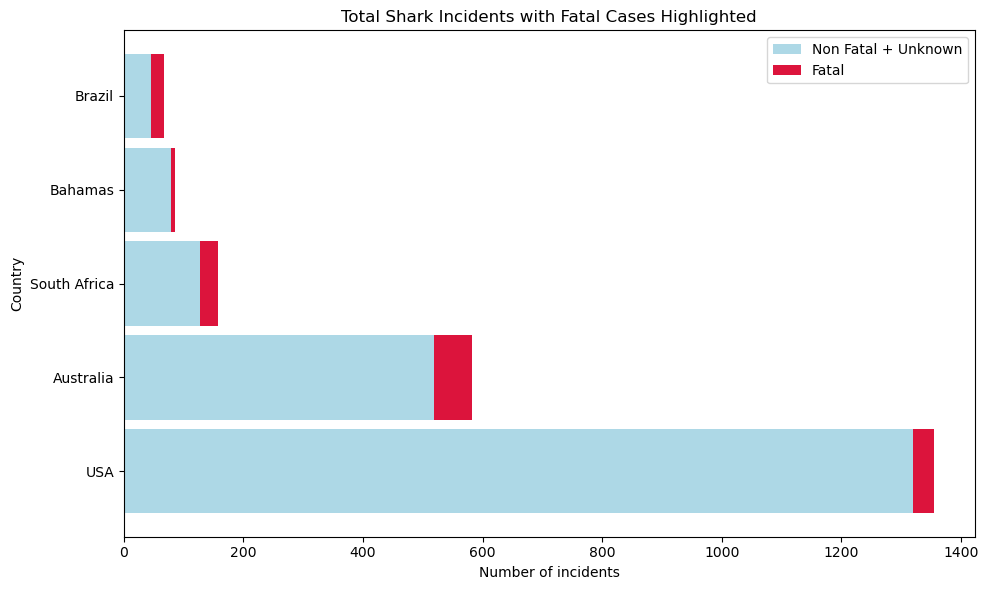

In [535]:
top5 = country_fatality.sort_values(by='Total', ascending=False).head(5).copy()
top5['Non Fatal'] = top5['N'] + top5['Unknown']

top5[['Non Fatal', 'Y']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=['lightblue', 'crimson'],
    width=0.9
)

plt.title('Total Shark Incidents with Fatal Cases Highlighted')
plt.xlabel('Number of incidents')
plt.ylabel('Country')
plt.legend(['Non Fatal + Unknown', 'Fatal'])
plt.tight_layout()
plt.show()


In [536]:
#2. Most Important Table for Second Tide

#Since prosthetics are relevant to severe injuries, create an injury analysis table.

##This table directly answers:

#"Where is there likely demand for prosthetic devices?"

In [537]:
gender_age = (
    shark_clean_final_df
    .groupby(["Sex", "Age_Group"])
    .size()
    .unstack(fill_value=0)
)

print(gender_age)

Age_Group  Adult  Child  Senior  Teenager
Sex                                      
F            334     72      16        93
M           1676    140      52       334
Unknown      114      1       0         3


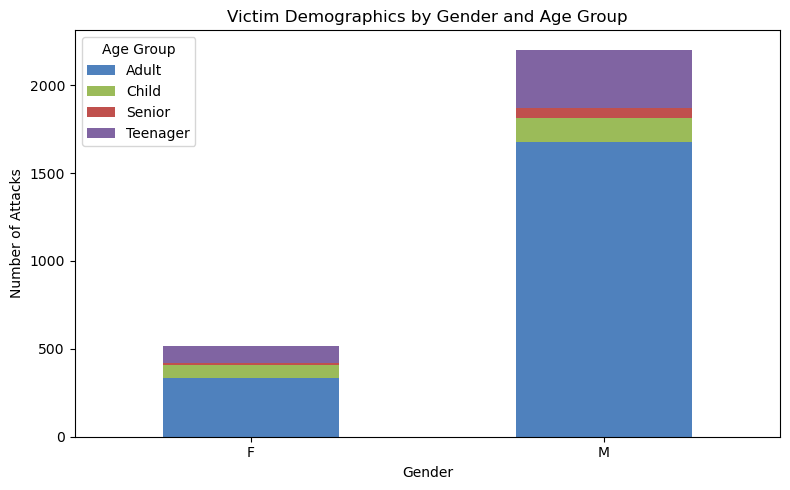

In [538]:
import matplotlib.pyplot as plt

# Remove Unknown category
gender_age_chart = gender_age.drop("Unknown")

# Choose your own colors here
colors = ["#4F81BD", "#9BBB59", "#C0504D", "#8064A2"]

ax = gender_age_chart.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=colors
)

plt.title("Victim Demographics by Gender and Age Group")
plt.xlabel("Gender")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=0)
plt.legend(title="Age Group")
plt.tight_layout()

plt.show()

In [539]:
#this is the code to be used for injuries
injury_country = (
    shark_clean_final_df.groupby(['Country', 'injury_group'])
      .size()
      .unstack(fill_value=0)
)

injury_country['Total'] = injury_country.sum(axis=1)


injury_country.sort_values(
    by='Total',
    ascending=False
).head(5)

injury_group,Amputation,Fatal,Minor Injury,No injury,Severe Injury,Unknown,Total
Country,,,,,,,
USA,16,37,1046,161,94,1,1355
Australia,7,62,318,143,48,5,583
South Africa,5,30,80,41,1,0,157
Bahamas,4,8,60,4,9,1,86
Brazil,7,21,35,1,3,0,67


In [540]:
# Find the top 5 countries
top_5_countries = (
    shark_clean_final_df["Country"]
    .value_counts()
    .head(5)
    .index
)

# Gender analysis for only the top 5 countries
gender_country = (
    shark_clean_final_df[
        shark_clean_final_df["Country"].isin(top_5_countries)
    ]
    .groupby(["Country", "Sex"])
    .size()
    .unstack(fill_value=0)
)
gender_country = gender_country.reindex(
    columns=["M", "F", "Unknown"],
    fill_value=0
)


print(gender_country)

Sex              M    F  Unknown
Country                         
Australia      483   69       31
Bahamas         60   25        1
Brazil          59    6        2
South Africa   139    6       12
USA           1009  312       34


In [541]:
#3. Age Group Analysis

#This is useful because prosthetic adoption differs by age.

#Create age bins:

In [542]:
#Step 1 in 3 pointer: Create the age group column: We have created this categorize_age function earlier 
#under age column section
shark_species_clean_df["Age_Group"] = shark_clean_final_df["Age"].apply(categorize_age)

In [543]:
#Step 2 in 3 pointer: Count incidents by age group

In [544]:
age_analysis = (
    shark_clean_final_df
    .groupby("Age_Group")
    .size()
    .reset_index(name="Number_of_Attacks")
)
print(age_analysis)

  Age_Group  Number_of_Attacks
0     Adult               2124
1     Child                213
2    Senior                 68
3  Teenager                430


In [545]:
#Step 3 in 3 pointer: Age group by country (very useful for your business case - Focusing on top 5 countries)

In [546]:
top5_age_analysis = (
    shark_clean_final_df[
        shark_clean_final_df["Country"].isin(top_5_countries)
    ]
    .groupby(["Country", "Age_Group"])
    .size()
    .unstack(fill_value=0)
)

# Rearrange the columns
top5_age_analysis = top5_age_analysis[
    ["Child", "Teenager", "Adult", "Senior"]
]

print(top5_age_analysis)

Age_Group     Child  Teenager  Adult  Senior
Country                                     
Australia        25        76    471      11
Bahamas           4         4     75       3
Brazil            6        19     42       0
South Africa      0        23    130       4
USA             150       264    907      34


In [547]:
top_5_countries = (
    shark_clean_final_df["Country"]
    .value_counts()
    .head(5)
    .index
)

# Keep only records from those countries
top_5_df = shark_clean_final_df[
    shark_clean_final_df["Country"].isin(top_5_countries)
]

# Group by Country and Age Group
country_age = (
    top_5_df
    .groupby(["Country", "Age_Group"])
    .size()
    .unstack(fill_value=0)
)

print(country_age)

Age_Group     Adult  Child  Senior  Teenager
Country                                     
Australia       471     25      11        76
Bahamas          75      4       3         4
Brazil           42      6       0        19
South Africa    130      0       4        23
USA             907    150      34       264


In [548]:
# Find the top 5 countries
top_5_countries = (
    shark_clean_final_df["Country"]
    .value_counts()
    .head(5)
    .index
)

# Gender analysis for only the top 5 countries
gender_country = (
    shark_clean_final_df[
        shark_clean_final_df["Country"].isin(top_5_countries)
    ]
    .groupby(["Country", "Sex"])
    .size()
    .unstack(fill_value=0)
)

print(gender_country)

Sex             F     M  Unknown
Country                         
Australia      69   483       31
Bahamas        25    60        1
Brazil          6    59        2
South Africa    6   139       12
USA           312  1009       34


Given the large amount of unknown, the approach that we will follow is, for each unknown, a potential solution is to have a look in the Country column and add the most common shark there, statistically speaking per shark incidents in those countries.

## Answering questions

In [549]:
#Clean DF:

shark_clean_final_df2 = shark_clean_final_df.copy()

In [550]:
shark_clean_final_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2835 entries, 0 to 2837
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Year                 2835 non-null   int64 
 1   Type                 2821 non-null   object
 2   Country              2835 non-null   object
 3   State                2717 non-null   object
 4   Location             2727 non-null   object
 5   Activity             2711 non-null   object
 6   Name                 2795 non-null   object
 7   Sex                  2835 non-null   object
 8   Age                  2835 non-null   int64 
 9   Injury               2826 non-null   object
 10  Fatal Y/N            2835 non-null   object
 11  Species              1848 non-null   object
 12  injury_normalized    2835 non-null   object
 13  injury_group         2835 non-null   object
 14  Age_Group            2835 non-null   object
 15  Species_normalized   2835 non-null   object
 16  activity_no

### 1. What is the most common victim profile?

In [551]:
shark_clean_final_df2.groupby(["Fatal Y/N","Sex"]).agg({
    "Sex":"count",    
    "Age":"mean"}).round(0)

Sex   Age
Fatal Y/N Sex                
N         F         396  29.0
          M        1640  30.0
          Unknown    85  28.0
Unknown   F          83  27.0
          M         333  31.0
          Unknown    21  29.0
Y         F          36  39.0
          M         229  35.0
          Unknown    12  28.0

The most common victim for both fatal and non fatal incidents are Males in their 30s

In [552]:
activity_fatality = (
    shark_clean_final_df.groupby(['activity_normalized', 'Fatal Y/N'])
      .size()
      .unstack(fill_value=0)
)
activity_fatality = activity_fatality.reindex(columns=['Y', 'N', 'Unknown'], fill_value=0)
activity_fatality['Total'] = activity_fatality.sum(axis=1)

activity_fatality.sort_values(
    by='Total',
    ascending=False
).head(6)



Fatal Y/N,Y,N,Unknown,Total
activity_normalized,,,,
Surfing,64,790,142,996
Swimming,105,516,118,739
Fishing,34,356,66,456
Diving,34,128,26,188
Unknown,16,77,36,129
Boating,9,91,10,110


In [553]:
#Added for better bifurcation of injury type against the activity
activity_injury = (
    shark_clean_final_df.groupby(['activity_normalized', 'injury_group'])
      .size()
      .unstack(fill_value=0)
)

activity_injury['Total'] = activity_injury.sum(axis=1)

activity_injury = activity_injury.sort_values(
    by='Total',
    ascending=False
)
activity_injury.head(6)

injury_group,Amputation,Fatal,Minor Injury,No injury,Severe Injury,Unknown,Total
activity_normalized,,,,,,,
Surfing,16,62,682,169,67,0,996
Swimming,37,106,514,9,71,2,739
Fishing,8,36,296,96,20,0,456
Diving,10,35,104,28,10,1,188
Unknown,3,13,101,6,2,4,129
Boating,1,8,26,73,1,1,110


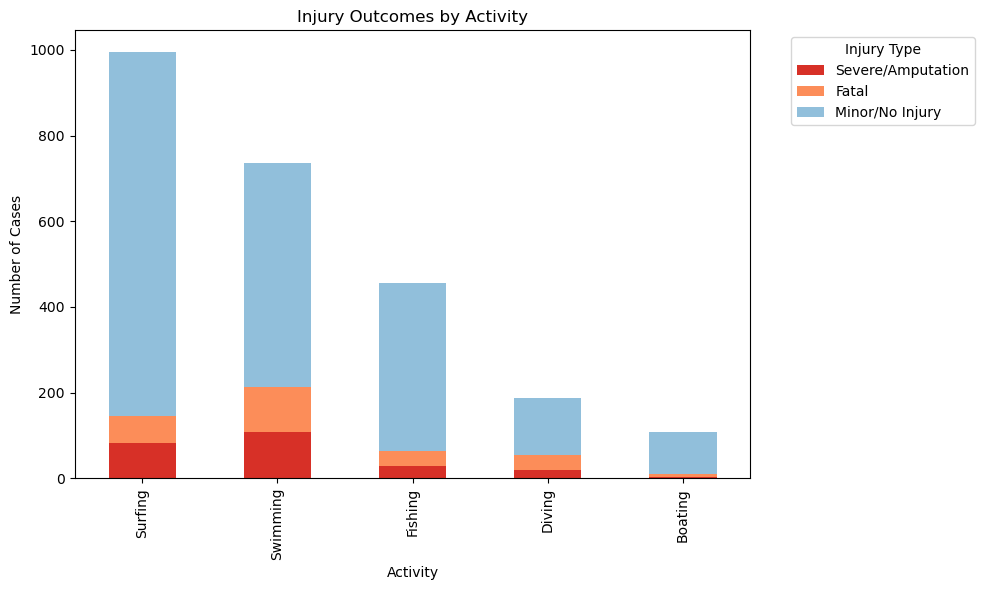

In [554]:
import pandas as pd
import matplotlib.pyplot as plt

activity_chart = pd.DataFrame({
    "Activity": ["Surfing", "Swimming", "Fishing", "Diving", "Boating"],
    "Severe/Amputation": [83, 108, 28, 20, 2],
    "Fatal": [62, 106, 36, 35, 8],
    "Minor/No Injury": [851, 523, 392, 132, 99],
    })

activity_chart = activity_chart.set_index("Activity")

# 🎨 EDIT COLOURS HERE
colors = {
    "Severe/Amputation": "#d73027",   # red
    "Fatal": "#fc8d59",              # orange
    "Minor/No Injury": "#91bfdb",    # blue
}

ax = activity_chart.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[colors[col] for col in activity_chart.columns]
)

plt.title("Injury Outcomes by Activity")
plt.ylabel("Number of Cases")
plt.xlabel("Activity")
plt.legend(title="Injury Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Surfing has the most shark incidents overall (996 total), with the highest number of non-fatal incidents (790), while swimming has the most fatal incidents (105 fatalities). Males in their 30s is the most common profile.

### 2. Which countries have the highest number of non-fatal attacks?

In [555]:
country_fatality = (
    shark_clean_final_df2.groupby(['Country', 'Fatal Y/N'])
      .size()
      .unstack(fill_value=0)
)

country_fatality['Total'] = country_fatality.sum(axis=1)

country_fatality.sort_values(
    by='Total',
    ascending=False
).head(5)

Fatal Y/N,N,Unknown,Y,Total
Country,,,,
USA,1118,201,36,1355
Australia,436,82,65,583
South Africa,103,24,30,157
Bahamas,63,16,7,86
Brazil,36,10,21,67


In [556]:
#Let's represent in a graph to display better the findings

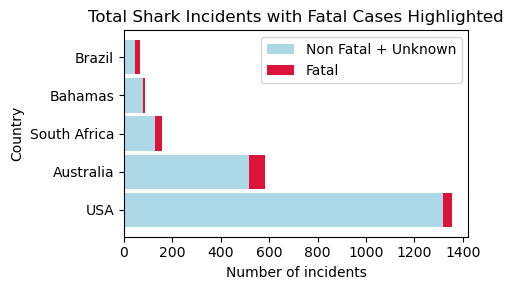

In [557]:
top5 = country_fatality.sort_values(by='Total', ascending=False).head(5).copy()
top5['Non Fatal'] = top5['N'] + top5['Unknown']

top5[['Non Fatal', 'Y']].plot(
    kind='barh',
    stacked=True,
    figsize=(5, 3),
    color=['lightblue', 'crimson'],
    width=0.9
)

plt.title('Total Shark Incidents with Fatal Cases Highlighted')
plt.xlabel('Number of incidents')
plt.ylabel('Country')
plt.legend(['Non Fatal + Unknown', 'Fatal'])
plt.tight_layout()
plt.show()


USA has the highest number of non lethal attacks but the mortality rate is higher in Australia.

In [558]:
#About species per country:
country_species = (
    shark_clean_final_df2.groupby(['Country', 'Species_normalized'])
      .size()
      .unstack(fill_value=0)
)

# Keep only top 5 species columns
top_5_species = country_species.sum(axis=0).sort_values(ascending=False).head(5).index.tolist()
country_species = country_species[top_5_species]

country_species['Total'] = country_species.sum(axis=1)

country_species.sort_values(
    by='Total',
    ascending=False
).head(5)


Species_normalized,Unknown,Shark (size described),White shark,Tiger shark,Bull shark,Total
Country,,,,,,
USA,627,247,104,95,73,1146
Australia,200,63,129,21,46,459
South Africa,49,11,57,6,4,127
Brazil,44,1,0,11,4,60
Bahamas,33,4,1,4,17,59


White sharks are the species more common in the top 5 countries with most attacks

### 3. Injuries

In [559]:
shark_clean_final_df2['injury_group'].value_counts()

injury_group
Minor Injury     1870
No injury         414
Fatal             278
Severe Injury     187
Amputation         77
Unknown             9
Name: count, dtype: int64

In [560]:
# Get total incidents by country (all injury groups, all fatality outcomes)
total_by_country = (
    shark_clean_final_df2.groupby('Country')
      .size()
)

# Get fatality counts (Y) by country
fatalities_by_country = (
    shark_clean_final_df2[shark_clean_final_df2['Fatal Y/N'] == 'Y']
    .groupby('Country')
    .size()
)

# Get non fatality counts (N) by country
no_fatalities_by_country = (
    shark_clean_final_df2[shark_clean_final_df2['Fatal Y/N'] == 'N']
    .groupby('Country')
    .size()
)

# Get amputation counts by country
amputations_by_country = (
    shark_clean_final_df2[shark_clean_final_df2['injury_group'] == 'Amputation']
    .groupby('Country')
    .size()
)
# Get severe counts by country
severe_injury_by_country = (
    shark_clean_final_df2[shark_clean_final_df2['injury_group'] == 'Severe Injury']
    .groupby('Country')
    .size()
)

# Create combined dataframe
country_rates = pd.DataFrame({
    'Total Incidents': total_by_country,
    'Surviving Cases': no_fatalities_by_country,
    'Severe Injuries': severe_injury_by_country,
    'Amputations': amputations_by_country,
    'Potential Prosthetic Clients': amputations_by_country + severe_injury_by_country
})

# Calculate rates
country_rates['Surviving Rate %'] = (
    country_rates['Surviving Cases'] / country_rates['Total Incidents']
).map(lambda x: f"{x * 100:.1f}%")

country_rates['Amputation Rate %'] = (
    country_rates['Amputations'] / country_rates['Total Incidents']
).map(lambda x: f"{x * 100:.1f}%")

country_rates['Severe Injury Rate %'] = (
    country_rates['Severe Injuries'] / country_rates['Total Incidents']
).map(lambda x: f"{x * 100:.1f}%")

# Key business metric: combined prosthetic potential
country_rates['Potential Prosthetic Clients Rate %'] = (
    country_rates['Potential Prosthetic Clients'] / country_rates['Total Incidents']
).map(lambda x: f"{x * 100:.1f}%")

# Sort by total incidents and show top 5
prostetic_potential_df = country_rates.sort_values(
    by='Total Incidents',
    ascending=False
).head(5)

prostetic_potential_df



,Total Incidents,Surviving Cases,Severe Injuries,Amputations,Potential Prosthetic Clients,Surviving Rate %,Amputation Rate %,Severe Injury Rate %,Potential Prosthetic Clients Rate %
Country,,,,,,,,,
USA,1355,1118.0,94.0,16.0,110.0,82.5%,1.2%,6.9%,8.1%
Australia,583,436.0,48.0,7.0,55.0,74.8%,1.2%,8.2%,9.4%
South Africa,157,103.0,1.0,5.0,6.0,65.6%,3.2%,0.6%,3.8%
Bahamas,86,63.0,9.0,4.0,13.0,73.3%,4.7%,10.5%,15.1%
Brazil,67,36.0,3.0,7.0,10.0,53.7%,10.4%,4.5%,14.9%


USA and Australia are the strongest markets by volume, with 110 and 55 potential prosthetic clients respectively, which represents the largest share of severe injuries and amputations in the dataset. They hold together 165 out of 194 total cases (85%). Although their rates are not the highest, their case volume makes them the most attractive business opportunities. They also have the highest survival rates, 82.5% in the USA and 74.8% in Australia, which suggests more survivors who may need prosthetic support. Bahamas and Brazil show higher rates, but their total case numbers are much lower, so they are better seen as secondary test markets rather than primary targets.

In [561]:
#Here's a cleaner version of the table:
summary_prostetic_potential_df = prostetic_potential_df[['Total Incidents', 'Surviving Rate %', 'Potential Prosthetic Clients', 'Potential Prosthetic Clients Rate %']]
summary_prostetic_potential_df

,Total Incidents,Surviving Rate %,Potential Prosthetic Clients,Potential Prosthetic Clients Rate %
Country,,,,
USA,1355,82.5%,110.0,8.1%
Australia,583,74.8%,55.0,9.4%
South Africa,157,65.6%,6.0,3.8%
Bahamas,86,73.3%,13.0,15.1%
Brazil,67,53.7%,10.0,14.9%


#### Which are the most common amputation types?

In [562]:
#shark_clean_final_df2['injury_group']

In [563]:
# Get all counts and filter for Amputation
injury_counts = shark_clean_final_df2.groupby('injury_normalized').size()

amputation_only = injury_counts[injury_counts.index.str.contains('Amputation')]
amputation_only = amputation_only.to_frame(name='Total')

# Sort descending by Total
amputation_only = amputation_only.sort_values(by='Total', ascending=False)
amputation_only


,Total
injury_normalized,
Amputation - arm,20
Amputation - leg,20
Amputation - hand,12
Amputation - forearm,9
Amputation - foot,7
Amputation - unspecified,4
Amputation - leg above knee,3
Amputation - fingers,1
Amputation - leg below knee,1


Upper and lower extremity amputations at the full limb level are predominant, with arm and leg amputations equally representing the highest frequency (20 cases each), followed by hand amputation (12).

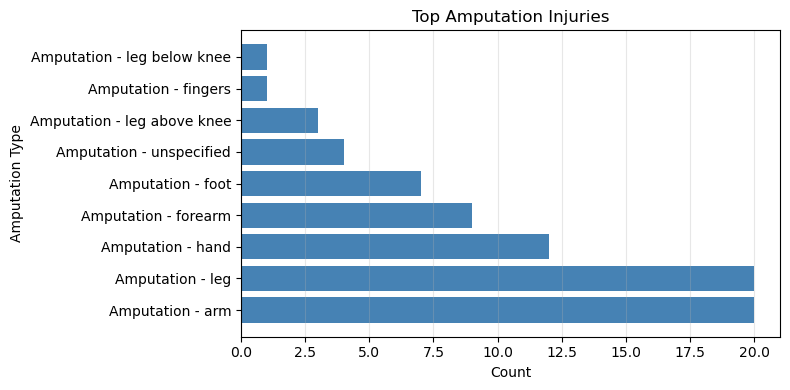

In [564]:
injury_counts = shark_clean_final_df2.groupby('injury_normalized').size()
amputation_only = injury_counts[injury_counts.index.str.contains('Amputation')]
amputation_only = amputation_only.sort_values(ascending=False)

# Create horizontal bar plot
plt.figure(figsize=(8, 4))
plt.barh(amputation_only.index, amputation_only.values, color='steelblue')

# Add labels and title
plt.xlabel('Count')
plt.ylabel('Amputation Type')
plt.title('Top Amputation Injuries')

# Add grid
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Injuries by age group and gender

In [565]:
injury_age_gender = (
    shark_clean_final_df[
        shark_clean_final_df["Sex"].isin(["F", "M"])
    ]
    .groupby(["injury_group", "Age_Group", "Sex"])
    .size()
    .unstack(["Age_Group", "Sex"], fill_value=0)
)

# Put age groups in the order you want
injury_age_gender = injury_age_gender.reindex(
    columns=[
        ("Child", "F"), ("Child", "M"),
        ("Teenager", "F"), ("Teenager", "M"),
        ("Adult", "F"), ("Adult", "M"),
        ("Senior", "F"), ("Senior", "M")
    ],
    fill_value=0
)

# Rename columns for readability
injury_age_gender.columns = [
    "Child Female", "Child Male",
    "Teen Female", "Teen Male",
    "Adult Female", "Adult Male",
    "Senior Female", "Senior Male"
]

injury_age_gender

,Child Female,Child Male,Teen Female,Teen Male,Adult Female,Adult Male,Senior Female,Senior Male
injury_group,,,,,,,,
Amputation,2,4,4,15,10,38,1,0
Fatal,1,1,6,29,24,190,5,11
Minor Injury,56,114,70,242,246,1058,9,33
No injury,1,6,6,27,23,285,0,7
Severe Injury,12,14,7,20,29,102,1,1
Unknown,0,1,0,1,2,3,0,0


In [566]:
table = injury_age_gender.reset_index()

print(table)

    injury_group  Child Female  Child Male  Teen Female  Teen Male  \
0     Amputation             2           4            4         15   
1          Fatal             1           1            6         29   
2   Minor Injury            56         114           70        242   
3      No injury             1           6            6         27   
4  Severe Injury            12          14            7         20   
5        Unknown             0           1            0          1   

   Adult Female  Adult Male  Senior Female  Senior Male  
0            10          38              1            0  
1            24         190              5           11  
2           246        1058              9           33  
3            23         285              0            7  
4            29         102              1            1  
5             2           3              0            0  


In [567]:
table.to_excel("injury_age_gender_table.xlsx", index=False)